# SpiderMark

**Spidermark** is a method for embedding invisible, robust watermarks into images generated by diffusion models. The technique modifies the *initial noise vector* in **Fourier space** before sampling begins, rather than altering the image afterward.

This ensures the watermark is:
-  **Invisible**: no post-processing artifacts,
-  **Robust**: invariant to common distortions (crop, rotate, JPEG, etc.),
-  **Detectable**: via inversion using the original diffusion model (e.g., DDIM).

---

### Basic Concept

Let $x_T \in \mathbb{R}^{C \times H \times W}$ be the initial Gaussian noise used to generate an image with a diffusion model.

We modify it in **Fourier space**:

$$
\mathcal{F}(x_T)_i =
\begin{cases}
k^*_i & \text{if } i \in \mathcal{M} \\
\mathcal{N}(0, 1) & \text{otherwise}
\end{cases}
$$

- $\mathcal{F}$ is the 2D Fourier transform (with shift),
- $\mathcal{M}$ is a mask (e.g. a ring around the center),
- $k^*$ is the **watermark key** inserted into that region.

After watermarking, we generate the image $x_0$ using the diffusion model:

$$
x_0 = D_\theta(x_T)
$$

To detect the watermark, we use **DDIM inversion**:

$$
x_T' = D_\theta^\dagger(x_0)
$$

Then we compute the **detection distance** (e.g., L1) in the masked Fourier region:

$$
\text{distance} = \frac{1}{|\mathcal{M}|} \sum_{i \in \mathcal{M}} \left| \mathcal{F}(x_T')_i - k^*_i \right|
$$

If this distance is below a threshold $\tau$, we conclude the image is watermarked.

---

### Why "Tree-Ring"?

The watermark pattern is often composed of **concentric rings** in Fourier space — similar to growth rings in a tree cross-section. This structure offers:
- **Rotational invariance**,
- **Robustness to spatial distortions**,
- **Statistical similarity to Gaussian noise** when properly designed.

---

In this notebook, we will:
1. Generate synthetic noise and a tree-ring pattern,
2. Embed the watermark into the noise,
3. Simulate forward and inverse diffusion,
4. Detect the watermark using the simplified detection formula above.

We assume you’re already familiar with how diffusion models work, and what DDIM is.

---

## Pretrained Diffusion Model

In this demo, we use the **pretrained diffusion model** provided by [OpenAI's Guided Diffusion repository](https://github.com/openai/guided-diffusion).

Specifically, we use the **256×256 class-conditional diffusion model trained on ImageNet**. This model is based on a large UNet architecture trained to reverse Gaussian noise into realistic images.

- It supports **DDPM** and **DDIM** sampling.
- It operates in **pixel space** rather than latent space.
- It accepts an optional **class label** as input (e.g., "dog", "car").

This model is ideal for our purposes because it:
- Allows us to inject a watermark directly into the **initial noise**,
- Supports **DDIM inversion**, which is essential for watermark detection,
- Is open-sourced and well-documented for reproducible research.

We do not retrain the model — instead, we treat it as a **frozen black box** that maps noise to image and image back to noise.



# 1. Prepare model and dataset

In [1]:
# Watermarking parameters
w_seed = 999999
w_channel = 0
# w_pattern = 'octoweb' 
w_pattern = 'ring' 
w_mask_shape = 'circle'
w_radius = 10
# w_measurement = 'l1_complex'
w_measurement = 'psnr_complex'
w_injection = 'complex'
w_pattern_const  = 0
w_strength = 0.99

Certainly! Here's a more detailed and technical extension of your original paragraph that explains the **functionality of each class and each key function** in `inverse_stable_diffusion.py` and `modified_stable_diffusion.py`:

---

With the help of custom scripts from Tree-Ring (`inverse_stable_diffusion.py` and `modified_stable_diffusion.py`), we extend the capabilities of the Stable Diffusion 2.1 model to support not only standard image generation from text prompts, but also **fine-grained latent space manipulation and DDIM inversion**. These enhancements are encapsulated in two custom pipeline classes:

---

## `ModifiedStableDiffusionPipeline`

This class subclasses Hugging Face's `StableDiffusionPipeline` and adds **custom functionality to support latent-level watermarking**, latent inspection, and extended output.

### Key Functionalities:

* **`__call__()`** **(Latent -> Image)**
  Acts as the main entry point for image generation. It supports standard prompt-to-image generation with extended arguments for Tree-Ring watermarking:

  * `watermarking_gamma`: probability mask for perturbing latents
  * `watermarking_delta`: perturbation strength
  * `watermarking_mask`: pre-defined binary mask for structured watermarking
    Additionally, it returns the original latent vector (`init_latents`) before denoising, which is critical for inversion or reconstruction workflows.

* **`get_image_latents(image, sample=True)`**
  Encodes an input image into the latent space using the VAE encoder. This function supports sampling from the distribution or returning the mode and is used for converting images back to latents prior to inversion.

---

## `InversableStableDiffusionPipeline`

This class extends `ModifiedStableDiffusionPipeline` by adding **support for DDIM inversion** (i.e., mapping from image → latent → original noise) and **prompt editing workflows**.

### Key Functionalities:

* **`backward_diffusion(...)`** **(Latent -> Image)**
  Although it's (Latent -> Image) pipeline, It's just the denoising loop, and doesn't do prompt tokenization, latent preparation, or decoding. Meanwhile, `ModifiedStableDiffusionPipeline.__call__()` is a complete, high-level pipeline that handles everything for you: prompt → latents → denoising → decoding → image + extras.
* **`forward_diffusion`** **(Image -> Latent)**
  A convenience alias (via `functools.partial`) that simply calls `backward_diffusion(reverse_process=True)` to perform a forward diffusion pass that is structurally consistent with the inversion routine.

* **`get_random_latents(...)`**
  Generates or returns random Gaussian latents suitable for input to the diffusion model, given image dimensions and device context.

* **`get_text_embedding(prompt)`**
  Tokenizes and encodes a text prompt into the text embedding space using the model’s tokenizer and text encoder. This is used to retrieve `encoder_hidden_states` for both generation and inversion.

---

Together, these classes provide a flexible, modular interface for the Tree-Ring watermarking framework, enabling researchers to:

* Embed watermarks by perturbing selected latent variables during generation,
* Generate images conditioned on textual prompts,
* Reconstruct the latent noise used in generation via DDIM inversion,
* Perform structured prompt editing (e.g., "Prompt-to-Prompt"),
* Visualize or save intermediate latent representations for further downstream analysis.

This modular design also enables easier integration with other watermark detection, evaluation, and manipulation components, making it a powerful research and debugging tool for latent space watermarking in diffusion models.

In [2]:
# Get the model.
import torch
from diffusers import DPMSolverMultistepScheduler
from inverse_stable_diffusion import InversableStableDiffusionPipeline

model_id = "stabilityai/stable-diffusion-2-1-base"
device = "cuda" if torch.cuda.is_available() else "cpu"
scheduler = DPMSolverMultistepScheduler.from_pretrained(model_id, subfolder="scheduler")
pipe = InversableStableDiffusionPipeline.from_pretrained(
    model_id,
    scheduler=scheduler,
    torch_dtype=torch.float16,
    revision="fp16",
)
pipe = pipe.to(device)

Couldn't connect to the Hub: 401 Client Error. (Request ID: Root=1-693b7b0a-5e9eac377722bf3f516aceea;dfcec112-79ed-40c6-972d-7f52353058b6)

Repository Not Found for url: https://huggingface.co/api/models/stabilityai/stable-diffusion-2-1-base/revision/fp16.
Please make sure you specified the correct `repo_id` and `repo_type`.
If you are trying to access a private or gated repo, make sure you are authenticated. For more details, see https://huggingface.co/docs/huggingface_hub/authentication
Invalid username or password..
Will try to load from local cache.


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

An error occurred while trying to fetch C:\Users\mike8\.cache\huggingface\hub\models--stabilityai--stable-diffusion-2-1-base\snapshots\1f758383196d38df1dfe523ddb1030f2bfab7741\unet: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\mike8\.cache\huggingface\hub\models--stabilityai--stable-diffusion-2-1-base\snapshots\1f758383196d38df1dfe523ddb1030f2bfab7741\unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch C:\Users\mike8\.cache\huggingface\hub\models--stabilityai--stable-diffusion-2-1-base\snapshots\1f758383196d38df1dfe523ddb1030f2bfab7741\vae: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\mike8\.cache\huggingface\hub\models--stabilityai--stable-diffusion-2-1-base\snapshots\1f758383196d38df1dfe523ddb1030f2bfab7741\vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
`torch_dtype` is deprecate

## Dataset: `Gustavosta/Stable-Diffusion-Prompts`

For this demo, we use the publicly available dataset [`Gustavosta/Stable-Diffusion-Prompts`](https://huggingface.co/datasets/Gustavosta/stable-diffusion-prompts), hosted on Hugging Face Datasets.

This dataset contains a curated collection of **high-quality text prompts** used to guide Stable Diffusion-style image generation. The prompts are designed to elicit rich, detailed, and creative visual scenes from text-to-image models.

### Dataset Highlights
- **Text-only** dataset — each sample is a prompt string.
- Originally intended for benchmarking prompt engineering in generative models.
- Useful for evaluating conditional generation, diversity, and robustness.

### Why we use it here:
- It provides a wide variety of realistic and artistic prompts.
- It enables repeatable generation and watermarking experiments across multiple prompt types.
- It is compact and easy to use, requiring no image storage.

We use this dataset to supply the **conditioning input (prompt)** for our diffusion model when generating watermarked and non-watermarked images.


In [3]:
# Prepare the dataset
from datasets import load_dataset
dataset = load_dataset('Gustavosta/Stable-Diffusion-Prompts')['test']
prompt_key = 'Prompt'

### Example of a prompt

In [4]:
"""
The instance contains `Prompt`, which is used to generate the image.
"""
dataset[0]

{'Prompt': 'young, curly haired, redhead Natalie Portman  as a optimistic!, cheerful, giddy medieval innkeeper in a dark medieval inn. dark shadows, colorful, candle light,  law contrasts, fantasy concept art by Jakub Rozalski, Jan Matejko, and J.Dickenson'}

# 2. Prepare the watermarking pattern ($k^*$), which will be injected into the image with the mask ($\mathcal{M}$).


In [5]:
# To mimic the real-world case, we assume the prompt is unknown at the detection time.
tester_prompt = '' 
text_embeddings = pipe.get_text_embedding(tester_prompt) # Generate the text embedding for the tester prompt, which is used to get the latent from given image (test image) through the forward diffusion process.

In [6]:
text_embeddings.shape # The text embedding is a 77x1024 tensor where 77 is the number of tokens in the prompt and 1024 is the dimension of the text embedding.

torch.Size([1, 77, 1024])

In [7]:
from utils.random import set_random_seed
import numpy as np
import copy

import warnings

warnings.filterwarnings("ignore", category=UserWarning, message=".*?.*?")
warnings.filterwarnings("ignore", category=FutureWarning, message=".*?.*?")


def circle_mask(size=64, r=10, x_offset=0, y_offset=0):
    """
    Create a circular mask of given size and radius.
    Parameters:
        - size: The size of the mask (width and height).
        - r: The radius of the circle.
        - x_offset: The x-coordinate offset for the center of the circle.
        - y_offset: The y-coordinate offset for the center of the circle.
    Returns:
        - mask: A boolean mask where True values represent the circular area.

    Reference: https://stackoverflow.com/questions/69687798/generating-a-soft-circluar-mask-using-numpy-python-3
    """
    x0 = y0 = size // 2
    x0 += x_offset
    y0 += y_offset
    y, x = np.ogrid[:size, :size]
    y = y[::-1]
    return ((x - x0) ** 2 + (y - y0) ** 2) <= r**2


import math
import copy
import torch
import torch.nn.functional as F
import numpy as np

# ------------------------
# Helpers
# ------------------------


def circle_mask(size=64, r=10, x_offset=0, y_offset=0):
    """Return a boolean NumPy circular mask (size x size) with radius r."""
    x0 = y0 = size // 2
    x0 += x_offset
    y0 += y_offset
    y, x = np.ogrid[:size, :size]
    y = y[::-1]
    return ((x - x0) ** 2 + (y - y0) ** 2) <= r**2


def _ensure_bchw(x, device=None, dtype=None):
    if not torch.is_tensor(x):
        raise TypeError("expected torch.Tensor")
    if x.ndim == 2:
        x = x.unsqueeze(0).unsqueeze(0)
    elif x.ndim == 3:
        x = x.unsqueeze(0)
    if device is not None:
        x = x.to(device)
    if dtype is not None:
        x = x.to(dtype)
    return x


def cartesian_to_logpolar(img, H_lp=None, W_lp=None, r_min=1.0, eps=1e-6):
    # img: (B,C,H,W)
    B, C, H, W = img.shape
    device = img.device
    dtype = img.dtype

    if H_lp is None:
        H_lp = H
    if W_lp is None:
        W_lp = W

    cx = (W - 1) / 2.0
    cy = (H - 1) / 2.0
    R_max = math.hypot(cx, cy)

    log_r_min = math.log(r_min + eps)
    log_r_max = math.log(R_max + eps)

    # radius samples (H_lp), use torch.linspace with positional steps
    r_lin = torch.exp(
        torch.linspace(log_r_min, log_r_max, H_lp, device=device, dtype=dtype)
    )
    # theta samples (W_lp) - use positional steps and endpoint=False
    theta_lin = torch.linspace(
        0.0, 2.0 * math.pi, W_lp, device=device, dtype=dtype, endpoint=False
    )

    r_grid, theta_grid = torch.meshgrid(r_lin, theta_lin, indexing="ij")  # (H_lp, W_lp)

    x = cx + r_grid * torch.cos(theta_grid)
    y = cy + r_grid * torch.sin(theta_grid)

    x_norm = (x / (W - 1)) * 2.0 - 1.0
    y_norm = (y / (H - 1)) * 2.0 - 1.0

    grid = torch.stack((x_norm, y_norm), dim=-1)  # (H_lp, W_lp, 2)
    grid = grid.unsqueeze(0).expand(B, -1, -1, -1)  # (B, H_lp, W_lp, 2)

    logpolar = F.grid_sample(
        img, grid, mode="bilinear", padding_mode="zeros", align_corners=True
    )
    return logpolar


def logpolar_to_cartesian(lp_img, out_H, out_W, r_min=1.0, eps=1e-6):
    B, C, H_lp, W_lp = lp_img.shape
    device = lp_img.device
    dtype = lp_img.dtype

    cx = (out_W - 1) / 2.0
    cy = (out_H - 1) / 2.0
    R_max = math.hypot(cx, cy)

    log_r_min = math.log(r_min + eps)
    log_r_max = math.log(R_max + eps)

    xs = torch.linspace(0.0, out_W - 1, out_W, device=device, dtype=dtype)
    ys = torch.linspace(0.0, out_H - 1, out_H, device=device, dtype=dtype)
    y_grid, x_grid = torch.meshgrid(ys, xs, indexing="ij")  # (out_H, out_W)

    dx = x_grid - cx
    dy = y_grid - cy
    r = torch.sqrt(dx * dx + dy * dy)
    theta = torch.atan2(dy, dx)
    theta = torch.where(theta < 0.0, theta + 2.0 * math.pi, theta)

    r_clamped = torch.clamp(r, min=1.0, max=R_max)
    log_r = torch.log(r_clamped + eps)
    u = (log_r - log_r_min) / (log_r_max - log_r_min)
    u = u.clamp(0.0, 1.0) * (H_lp - 1)

    v = (theta / (2.0 * math.pi)) * (W_lp - 1)

    x_src = (v / (W_lp - 1)) * 2.0 - 1.0
    y_src = (u / (H_lp - 1)) * 2.0 - 1.0

    grid = torch.stack((x_src, y_src), dim=-1).unsqueeze(0).expand(B, -1, -1, -1)
    cart = F.grid_sample(
        lp_img, grid, mode="bilinear", padding_mode="zeros", align_corners=True
    )
    return cart


def generate_logpolar_grid(
    H_lp, W_lp, n_spokes=16, n_rings=12, device="cpu", dtype=torch.float16
):
    """
    Create a synthetic log-polar canvas that contains both concentric rings and radial spokes.
    Output shape: (1,1,H_lp,W_lp) - single-channel; you can expand to match channels.
    """
    # normalized coords u in [0,1] for radius index, v in [0,1) for theta
    u = torch.linspace(0.0, 1.0, H_lp, device=device, dtype=dtype).view(H_lp, 1)
    v = torch.linspace(0.0, 1.0, W_lp, device=device, dtype=dtype).view(1, W_lp)

    # ring pattern: sinusoidal in log-radius (higher frequency near center if desired)
    rings = 0.5 * (1.0 + torch.sign(torch.sin(u * n_rings * math.pi)))  # coarse rings
    # alternative smoother rings (uncomment if you prefer smooth):
    # rings = 0.5 * (1.0 + torch.sin(u * n_rings * math.pi))

    # spoke pattern: sinusoidal in angle
    spokes = 0.5 * (1.0 + torch.sin(v * n_spokes * 2.0 * math.pi))

    # combine them multiplicatively (or additively) to produce grid intersections
    lp = rings * spokes  # shape (H_lp, W_lp)
    lp = lp.unsqueeze(0).unsqueeze(0)  # (1,1,H_lp,W_lp)
    return lp.to(device=device, dtype=dtype)


import torch
import math


def generate_spiderweb_grid(
    H: int,
    W: int,
    *,
    n_spokes: int,
    n_rings: int,
    jitter_amplitude: float = 0.15,
    device=None,
    dtype=torch.float32,
):
    """
    Returns [1,1,H,W] spiderweb mask:
    - concentric curved rings
    - radial spokes (slightly curved)
    We build it in polar coordinates (r,theta) then rasterize.
    Values ~1 on web lines, ~0 elsewhere.
    """
    device = device or "cpu"

    # normalised coordinate system, centre = (0,0)
    ys = torch.linspace(-1.0, 1.0, steps=H, device=device, dtype=dtype)
    xs = torch.linspace(-1.0, 1.0, steps=W, device=device, dtype=dtype)
    yy, xx = torch.meshgrid(ys, xs, indexing="ij")

    # convert to polar
    r = torch.sqrt(xx**2 + yy**2)  # [0, ~1.41]
    theta = torch.atan2(yy, xx)  # [-pi, pi]

    # normalise radius to [0,1]
    r_norm = r / r.max().clamp(min=1e-8)

    # ----- curved rings -----
    # base ring positions linearly spaced in radius
    ring_pos = torch.linspace(0.05, 1.0, steps=n_rings, device=device, dtype=dtype)

    # distance from each pixel's r_norm to nearest (possibly wobbled) ring
    # add sinusoidal jitter so the rings aren't perfect circles
    # jitter depends on theta -> makes arcs look organic
    # shape: [n_rings, H, W]
    ring_jitter = torch.sin(theta * 3.0) * jitter_amplitude  # [-A, A]
    # broadcast ring_pos to [n_rings,1,1]
    ring_pos = ring_pos.view(-1, 1, 1)
    ring_delta = torch.abs(r_norm.unsqueeze(0) - (ring_pos + ring_jitter.unsqueeze(0)))
    # take min across rings -> how close am I to ANY ring?
    ring_strength = torch.exp(-(ring_delta * 80.0))  # sharp falloff

    # ----- radial spokes -----
    # spoke angles
    spoke_angles = torch.linspace(
        -math.pi, math.pi, steps=n_spokes + 1, device=device, dtype=dtype
    )[:-1]

    # each spoke gets a tiny theta bend that depends on radius, so lines aren't perfectly straight
    # shape: [n_spokes, H, W]
    theta_expanded = theta.unsqueeze(0)
    r_norm_expanded = r_norm.unsqueeze(0)
    spoke_delta_list = []
    for ang in spoke_angles:
        # bend: spoke angle shifts slightly outward w/ radius using a sinusoid
        bend = ang + (
            r_norm_expanded[0] * 0.3 * torch.sin(r_norm_expanded[0] * 6.0 + ang * 4.0)
        )
        # angular distance wrap-around safe
        raw = torch.remainder(theta_expanded[0] - bend + math.pi, 2 * math.pi) - math.pi
        spoke_delta_list.append(raw.abs().unsqueeze(0))
    spoke_delta = torch.cat(spoke_delta_list, dim=0)  # [n_spokes, H, W]
    spoke_strength = torch.exp(-(spoke_delta * 50.0))  # thin spokes

    # combine rings + spokes
    web_strength = torch.clamp(
        ring_strength.max(dim=0).values + spoke_strength.max(dim=0).values, 0.0, 1.0
    )

    # fade outer border so edges aren't harsh squares
    edge_mask = (r_norm <= 1.0).float()
    web_strength = web_strength * edge_mask

    return web_strength.unsqueeze(0).unsqueeze(0)  # [1,1,H,W]


import torch
import math

import torch
import math


def _segment_distance(px, py, x0, y0, x1, y1):
    # distance from point P=(px,py) to segment (x0,y0)->(x1,y1)
    APx = px - x0
    APy = py - y0
    ABx = x1 - x0
    ABy = y1 - y0
    AB_len2 = ABx * ABx + ABy * ABy + 1e-12

    t = (APx * ABx + APy * ABy) / AB_len2
    t = t.clamp(0.0, 1.0)
    projx = x0 + t * ABx
    projy = y0 + t * ABy
    dx = px - projx
    dy = py - projy
    return torch.sqrt(dx * dx + dy * dy + 1e-12)


def generate_octoweb_grid_strict(
    H: int,
    W: int,
    *,
    n_rings: int,
    line_thickness: float = 0.02,
    device=None,
    dtype=torch.float32,
):
    """
    Returns [1,1,H,W] mask in {0,1} that looks like:
    - 8 spokes (0,45,...,315 deg) drawn from center
    - n_rings concentric 8-sided polygons (straight edges)
    """
    device = device or "cpu"
    ys = torch.linspace(-1.0, 1.0, steps=H, device=device, dtype=dtype)
    xs = torch.linspace(-1.0, 1.0, steps=W, device=device, dtype=dtype)
    yy, xx = torch.meshgrid(ys, xs, indexing="ij")  # [H,W]

    # how far from center each ring is (0.15 .. 1.0)
    ring_radii = torch.linspace(0.15, 1.0, steps=n_rings, device=device, dtype=dtype)

    # 8 spokes, every 45 degrees
    spoke_angles = torch.linspace(0, 2 * math.pi, steps=9, device=device, dtype=dtype)[
        :-1
    ]

    # collect min distance to ANY line (spoke or polygon edge)
    dists = []

    # spokes: segment from (0,0) to (cos a, sin a)
    for ang in spoke_angles:
        x1 = torch.cos(ang)
        y1 = torch.sin(ang)
        d_spoke = _segment_distance(
            xx,
            yy,
            torch.tensor(0.0, device=device, dtype=dtype),
            torch.tensor(0.0, device=device, dtype=dtype),
            x1,
            y1,
        )
        dists.append(d_spoke)

    # polygons: for each ring radius r_i
    for r_i in ring_radii:
        vx = r_i * torch.cos(spoke_angles)  # [8]
        vy = r_i * torch.sin(spoke_angles)  # [8]

        for k in range(8):
            x0 = vx[k]
            y0 = vy[k]
            x1 = vx[(k + 1) % 8]
            y1 = vy[(k + 1) % 8]

            d_edge = _segment_distance(xx, yy, x0, y0, x1, y1)
            dists.append(d_edge)

    # stack and take min distance to any web line
    d_all = torch.stack(dists, dim=0)  # [N,H,W]
    d_min = d_all.min(dim=0).values  # [H,W]

    # binary "is-on-a-line?" mask
    web_mask = (d_min <= line_thickness).float()

    # crop to circle so corners aren't noisy
    rr = torch.sqrt(xx**2 + yy**2)
    web_mask = torch.where(rr <= 1.0, web_mask, torch.zeros_like(web_mask))

    # shape [1,1,H,W]
    return web_mask.unsqueeze(0).unsqueeze(0)


def generate_octoweb_grid_draw(
    H: int,
    W: int,
    *,
    n_rings: int = 8,
    line_thickness: float = 0.015,
    device=None,
    dtype=torch.float32,
):
    """
    Creates a clean 8-sided spider web:
      - 8 straight spokes
      - n_rings octagonal rings connecting them
    Output: [1,1,H,W] in {0,1}
    """
    device = device or "cpu"
    ys = torch.linspace(-1.0, 1.0, steps=H, device=device, dtype=dtype)
    xs = torch.linspace(-1.0, 1.0, steps=W, device=device, dtype=dtype)
    yy, xx = torch.meshgrid(ys, xs, indexing="ij")

    mask = torch.zeros((H, W), device=device, dtype=dtype)

    # Parameters
    angles = torch.linspace(0, 2 * math.pi, steps=9, device=device)[:-1]
    ring_radii = torch.linspace(0.1, 1.0, steps=n_rings, device=device)

    # Draw spokes
    for ang in angles:
        x1, y1 = torch.cos(ang), torch.sin(ang)
        dist = torch.abs(xx * y1 - yy * x1)  # distance to line through origin
        dist /= torch.sqrt(x1**2 + y1**2)
        mask = torch.maximum(mask, (dist < line_thickness).float())

    # Draw octagonal rings
    for r in ring_radii:
        vx = (r * torch.cos(angles)).tolist()
        vy = (r * torch.sin(angles)).tolist()
        for i in range(8):
            x0, y0 = vx[i], vy[i]
            x1, y1 = vx[(i + 1) % 8], vy[(i + 1) % 8]
            # line equation
            ABx, ABy = x1 - x0, y1 - y0
            num = torch.abs((yy - y0) * ABx - (xx - x0) * ABy)
            den = math.sqrt(ABx**2 + ABy**2)
            dist = num / (den + 1e-12)
            mask = torch.maximum(mask, (dist < line_thickness).float())

    # Clip to circle
    rr = torch.sqrt(xx**2 + yy**2)
    mask = torch.where(rr <= 1.0, mask, torch.zeros_like(mask))

    return mask.unsqueeze(0).unsqueeze(0)


def _draw_segment(canvas, x0, y0, x1, y1, thickness_px):
    """
    Mutates canvas[H,W] in-place (bool OR).
    (x0,y0)->(x1,y1) are in pixel coords: x = column index, y = row index.
    thickness_px is radius in pixels.
    """
    H, W = canvas.shape
    device = canvas.device
    dtype = torch.float32

    ys = torch.arange(H, device=device, dtype=dtype).view(H, 1)
    xs = torch.arange(W, device=device, dtype=dtype).view(1, W)

    ABx = x1 - x0
    ABy = y1 - y0
    AB_len2 = ABx * ABx + ABy * ABy + 1e-12

    APx = xs - x0
    APy = ys - y0

    t = (APx * ABx + APy * ABy) / AB_len2
    t = t.clamp(0.0, 1.0)

    projx = x0 + t * ABx
    projy = y0 + t * ABy

    dx = xs - projx
    dy = ys - projy
    dist = torch.sqrt(dx * dx + dy * dy + 1e-12)

    canvas |= dist <= thickness_px


def generate_regular_spiderweb(
    H: int,
    W: int,
    *,
    n_spokes: int = 8,
    n_levels: int = 10,
    thickness_px: float = 2.0,
    max_r_frac: float = 0.45,  # how large the web is relative to min(H,W)
    device=None,
    dtype=torch.float32,
):
    """
    Returns [1,1,H,W] float {0,1}:
    - hub at image centre
    - n_spokes straight radial spokes (evenly spaced 360/n_spokes apart)
    - n_levels straight connectors between adjacent spokes at equal normalized radii
    This matches the clean geometric web you asked for.
    """
    device = device or "cpu"

    canvas = torch.zeros((H, W), dtype=torch.bool, device=device)

    # hub in the middle of the canvas
    hub_x = (W - 1) / 2.0
    hub_y = (H - 1) / 2.0

    # evenly spaced spokes
    angles = torch.linspace(
        0,
        2 * math.pi,
        steps=n_spokes + 1,
        device=device,
        dtype=dtype,
    )[
        :-1
    ]  # shape [n_spokes]

    # use same length for every spoke so it's not skewed
    max_r = min(H, W) * max_r_frac  # pixel radius of outer ring

    dir_x = torch.cos(angles)  # [n_spokes]
    dir_y = torch.sin(angles)  # [n_spokes]

    # radial checkpoints along each spoke:
    # start at 0.10 (not 0.0) so centre isn't a solid blob
    ts = torch.linspace(
        0.10,
        1.00,
        steps=n_levels,
        device=device,
        dtype=dtype,
    )  # [n_levels]

    # spoke_points_x[i, k] = x coord of level k on spoke i
    # spoke_points_y[i, k] = y coord of level k on spoke i
    spoke_points_x = hub_x + ts.view(1, -1) * (dir_x.view(-1, 1) * max_r)
    spoke_points_y = hub_y + ts.view(1, -1) * (dir_y.view(-1, 1) * max_r)
    # shapes: [n_spokes, n_levels]

    # 1. draw each spoke from hub to its outermost checkpoint
    for i in range(n_spokes):
        x0, y0 = hub_x, hub_y
        x1 = spoke_points_x[i, -1].item()
        y1 = spoke_points_y[i, -1].item()
        _draw_segment(canvas, x0, y0, x1, y1, thickness_px)

    # 2. draw connectors at each level between adjacent spokes
    # this creates the polygonal "rings"
    for k in range(n_levels):
        for i in range(n_spokes):
            j = (i + 1) % n_spokes  # neighbor spoke, wraps around
            x0 = spoke_points_x[i, k].item()
            y0 = spoke_points_y[i, k].item()
            x1 = spoke_points_x[j, k].item()
            y1 = spoke_points_y[j, k].item()
            _draw_segment(canvas, x0, y0, x1, y1, thickness_px)

    # convert bool -> float32 and shape -> [1,1,H,W]
    return canvas.float().unsqueeze(0).unsqueeze(0)



from watermark import get_watermarking_pattern

In [8]:
gt_patch = get_watermarking_pattern(
    pipe,
    w_seed=w_seed,
    w_pattern=w_pattern,
    w_radius=w_radius,
    device=device,
    strength=w_strength,
    shape=None,
)


## Visualise different patterns of watermarking

In [9]:
import matplotlib.pyplot as plt

def visualise_noise(x):
    """
    Visualize the noise or pattern.
    """
    # Convert the tensor to a numpy array and move it to CPU
    x_np = x.real.cpu().numpy()

    fig, axes = plt.subplots(1, x_np.shape[0], figsize=(x_np.shape[0] * 5, 5))
    for idx, ax in enumerate(axes):
        ax.imshow(x_np[idx], cmap="gray")
        ax.set_title(f"Channel {idx}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

### `w_pattern` Options for Watermarked Noise

The `get_watermarking_pattern(...)` function generates a structured noise tensor $x_T \in \mathbb{R}^{B \times C \times H \times W}$ used as input to the diffusion model. The type of watermark embedded into this tensor is controlled by the `w_pattern` argument.

Below is a summary of each supported pattern:

| Pattern      | Domain      | Description                                                                                                                                                                                                                                |
| ------------ | ----------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| `seed_rand`  | Spatial     | Uses randomly sampled Gaussian noise (standard baseline). No modification or watermark is applied.                                                                                                                                         |
| `seed_ring`  | Spatial     | Replaces ring-shaped spatial regions with constant values drawn from the center of each channel. Applies a circular mask in **spatial** domain, creating visible ring structures in the latent.                                            |
| `seed_zeros` | Spatial     | Replaces all latent values with zeros. This is used as a control to test the effect of removing all noise content.                                                                                                                         |
| `rand`       | **Fourier** | Applies 2D FFT and `fftshift` to the latent, then replaces the **entire frequency spectrum** with a single sample. All values become identical in Fourier space.                                                                           |
| `zeros`      | **Fourier** | Applies 2D FFT and `fftshift`, then zeros out the **entire frequency spectrum**, effectively nullifying the latent content.                                                                                                                |
| `const`      | **Fourier** | Applies 2D FFT and `fftshift`, zeros out the frequency space, then adds a predefined constant value (defined externally as `w_pattern_const`) to all frequencies.                                                                          |
| `ring`       | **Fourier** | Applies 2D FFT and `fftshift`, then injects constant values into a **ring-shaped region** defined by `w_radius` in the Fourier domain. This is the primary Tree-Ring watermarking mode. The rest of the frequency space remains untouched. |

#### 📌 Fourier Transform Notes

* All patterns that operate in the Fourier domain apply:

  ```python
  torch.fft.fft2(...), then torch.fft.fftshift(...)
  ```

  This ensures watermark keys are injected into **centered frequency coordinates**, making it easier to define radial masks like rings.

* Only `ring`, `rand`, `zeros`, and `const` modify the latent in **frequency space**.



Pattern: rand
torch.complex32


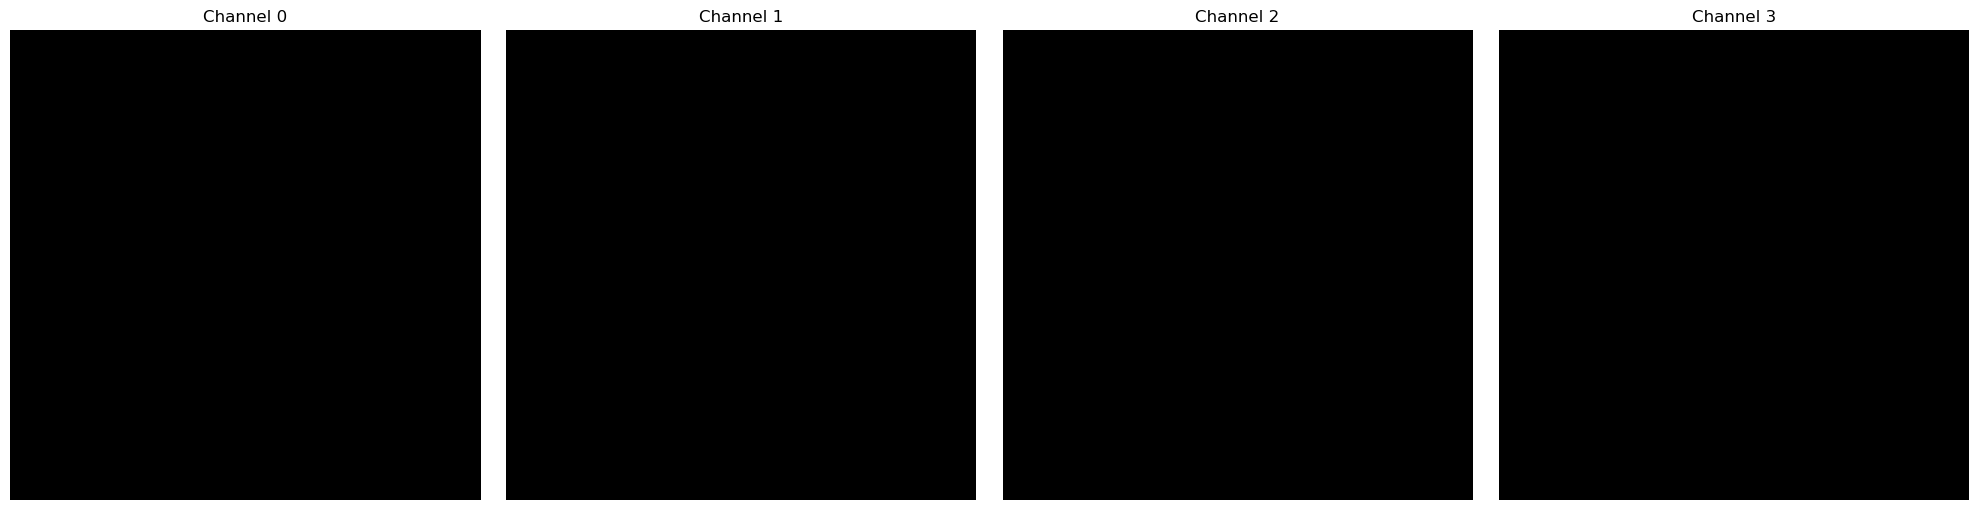

Pattern: zeros
torch.complex32


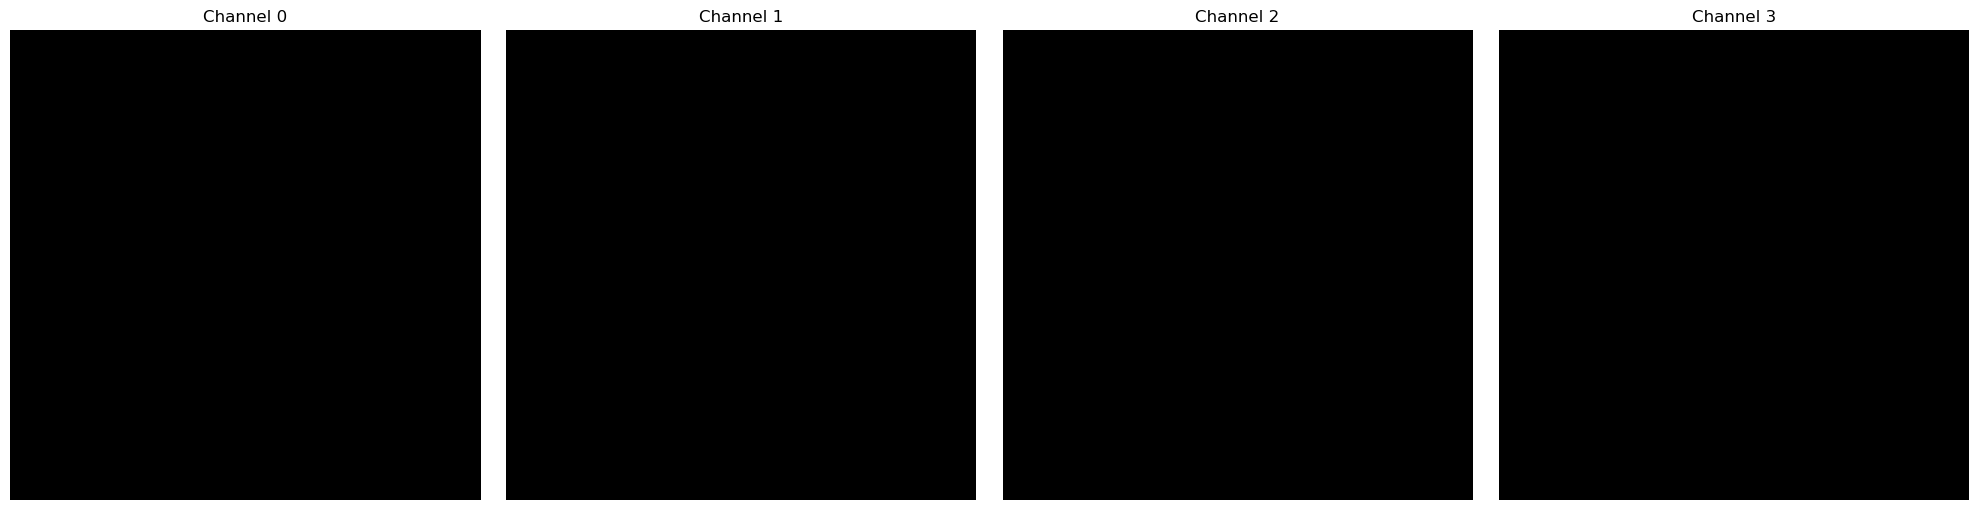

Pattern: const
torch.complex32


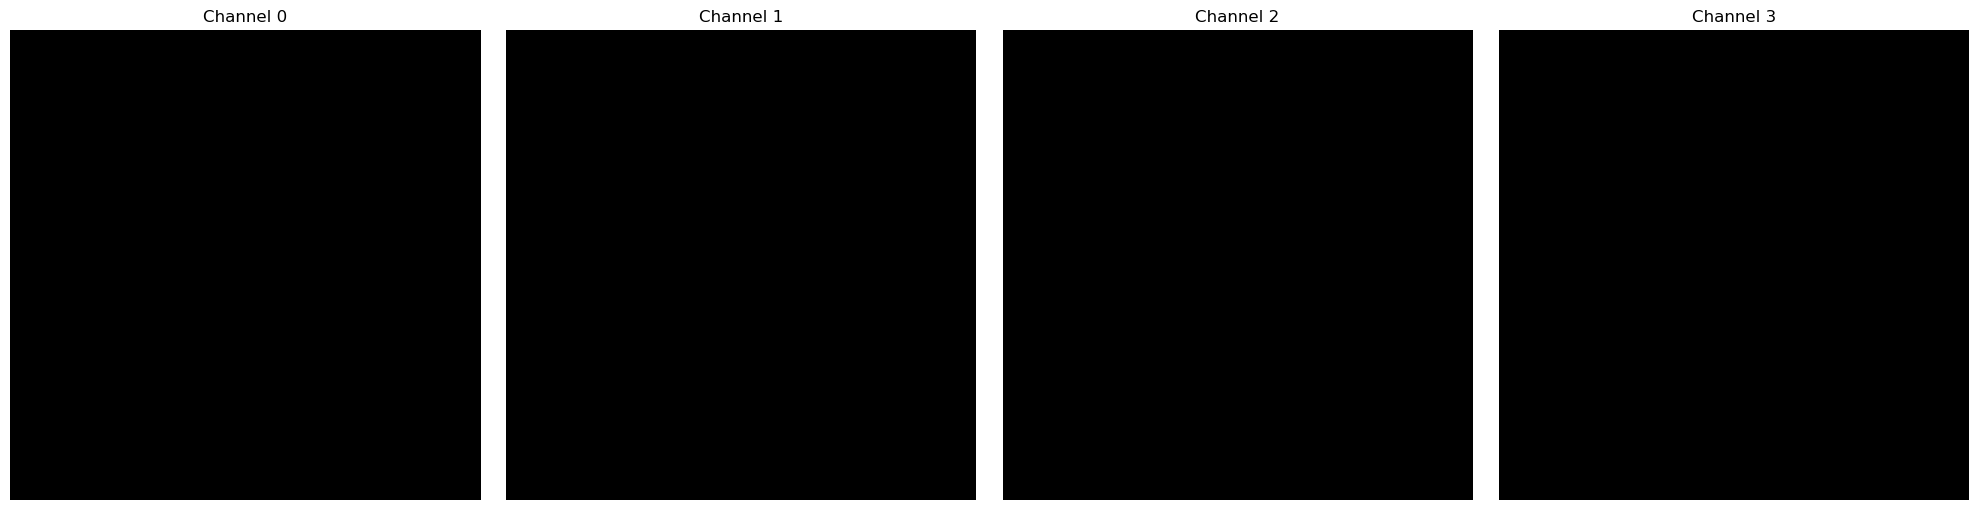

Pattern: seed_rand
torch.complex32


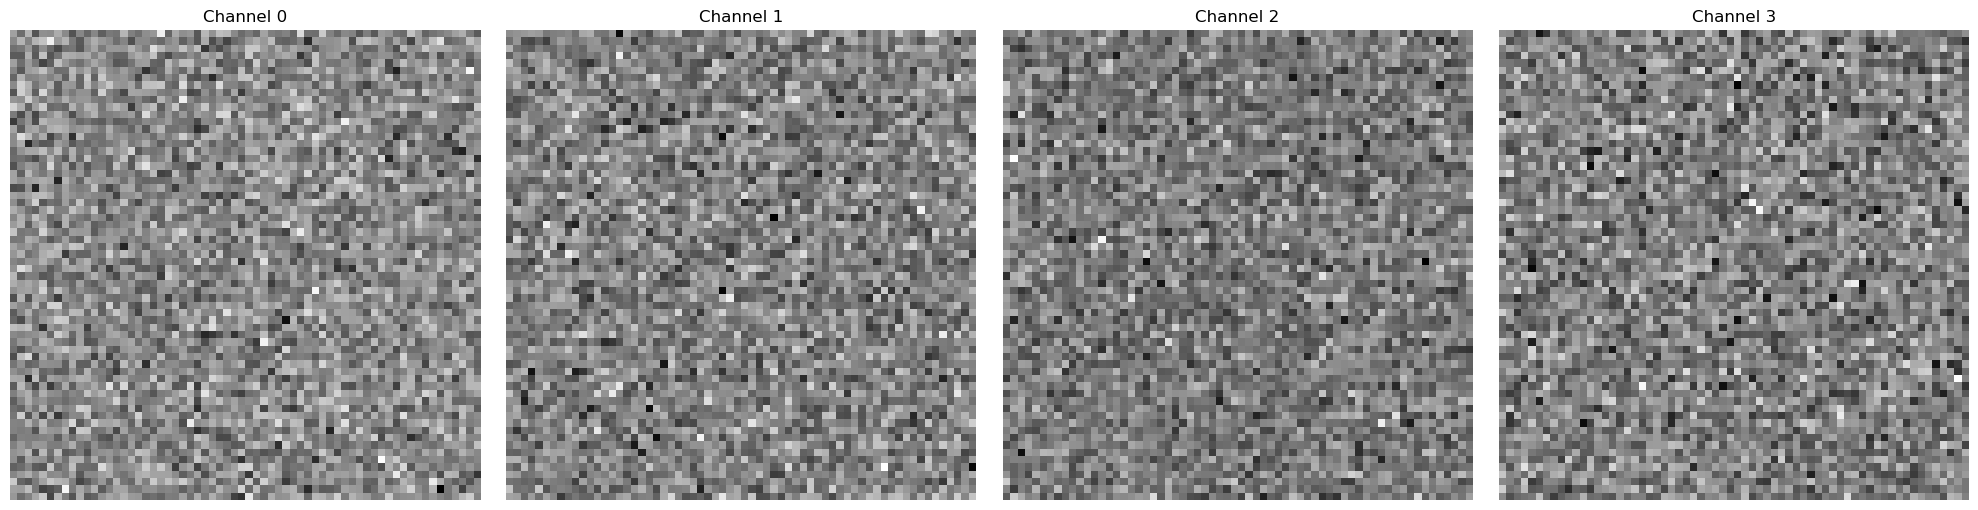

Pattern: seed_zeros
torch.complex32


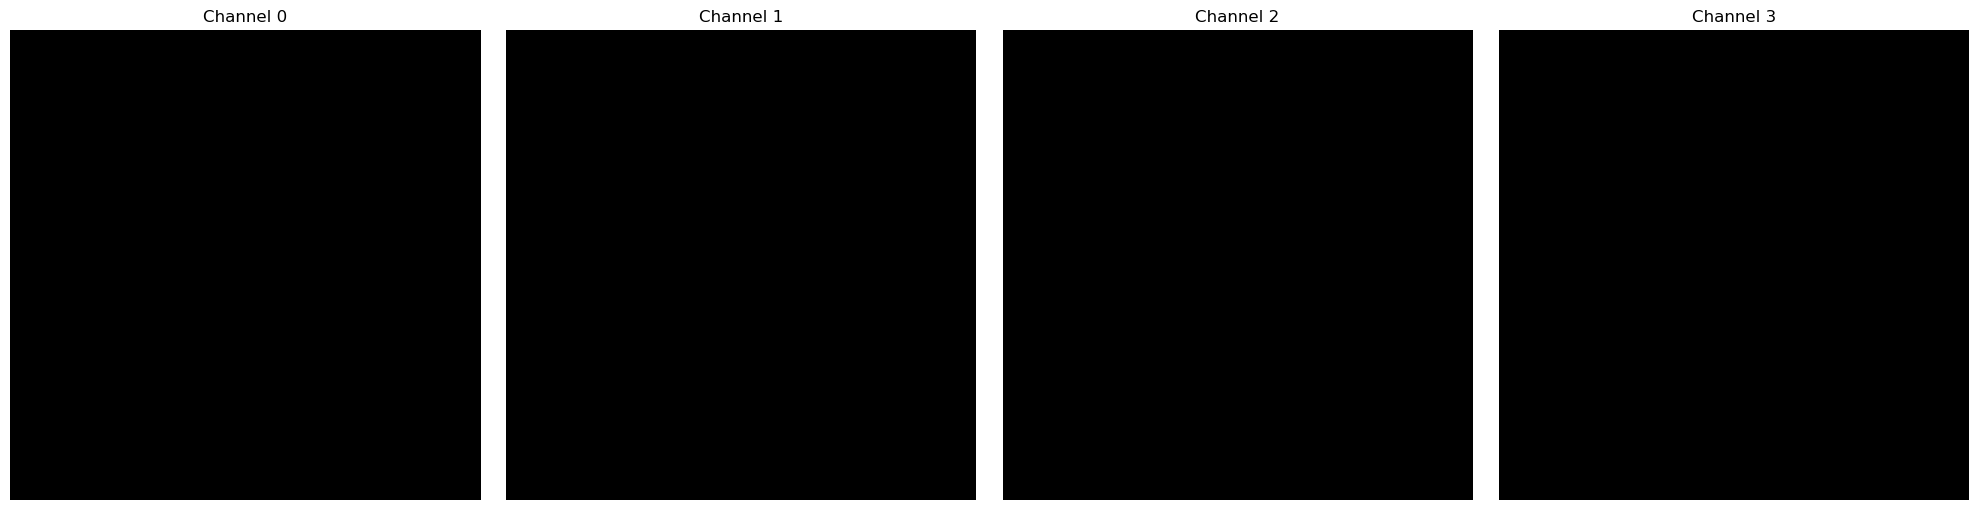

Pattern: seed_ring
torch.complex32


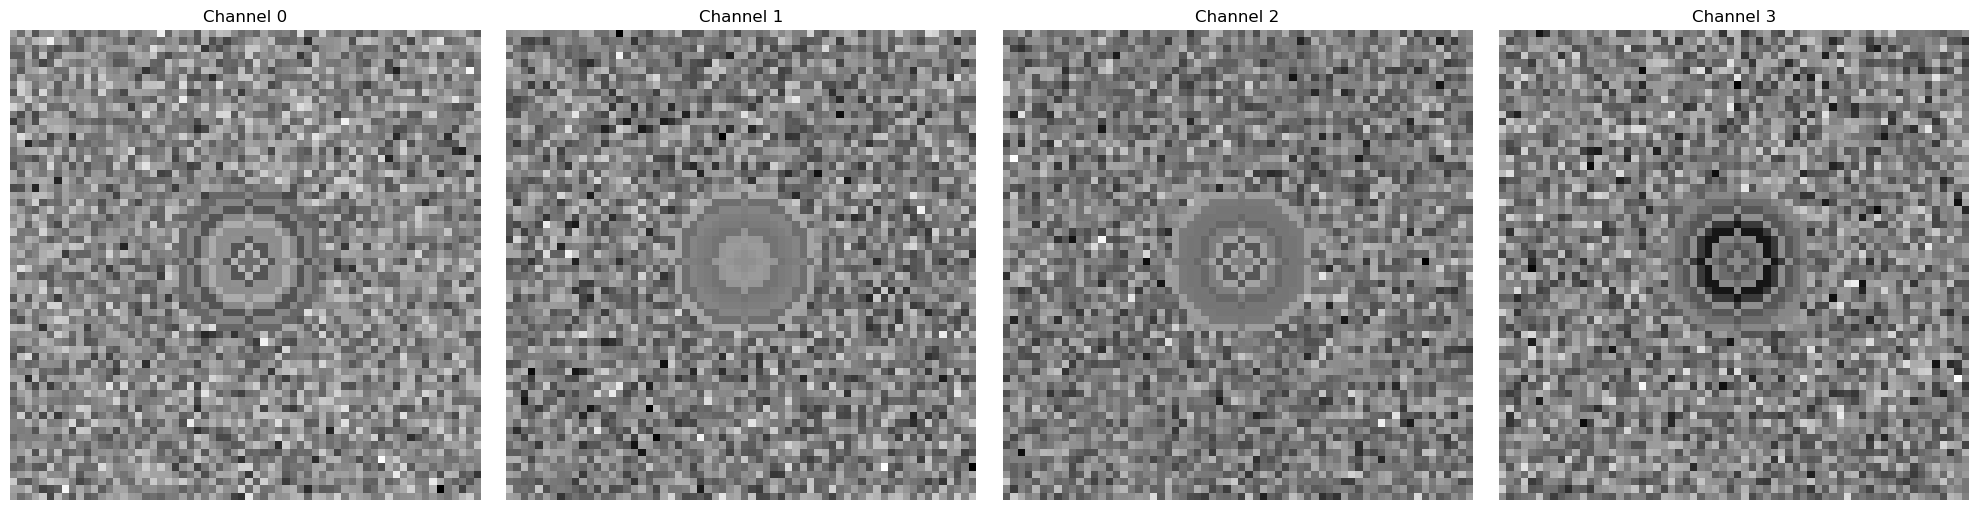

Pattern: ring
torch.complex32


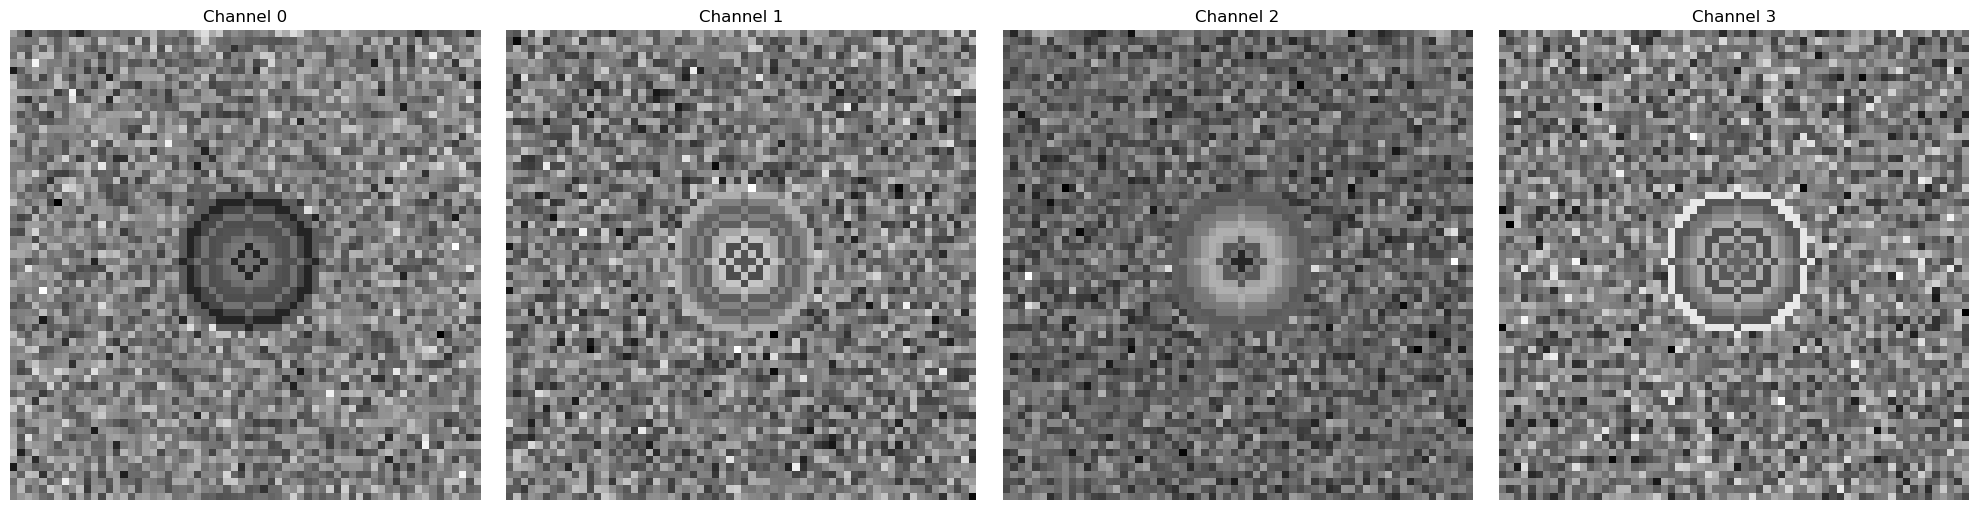

Pattern: logpolar_grid
torch.complex32


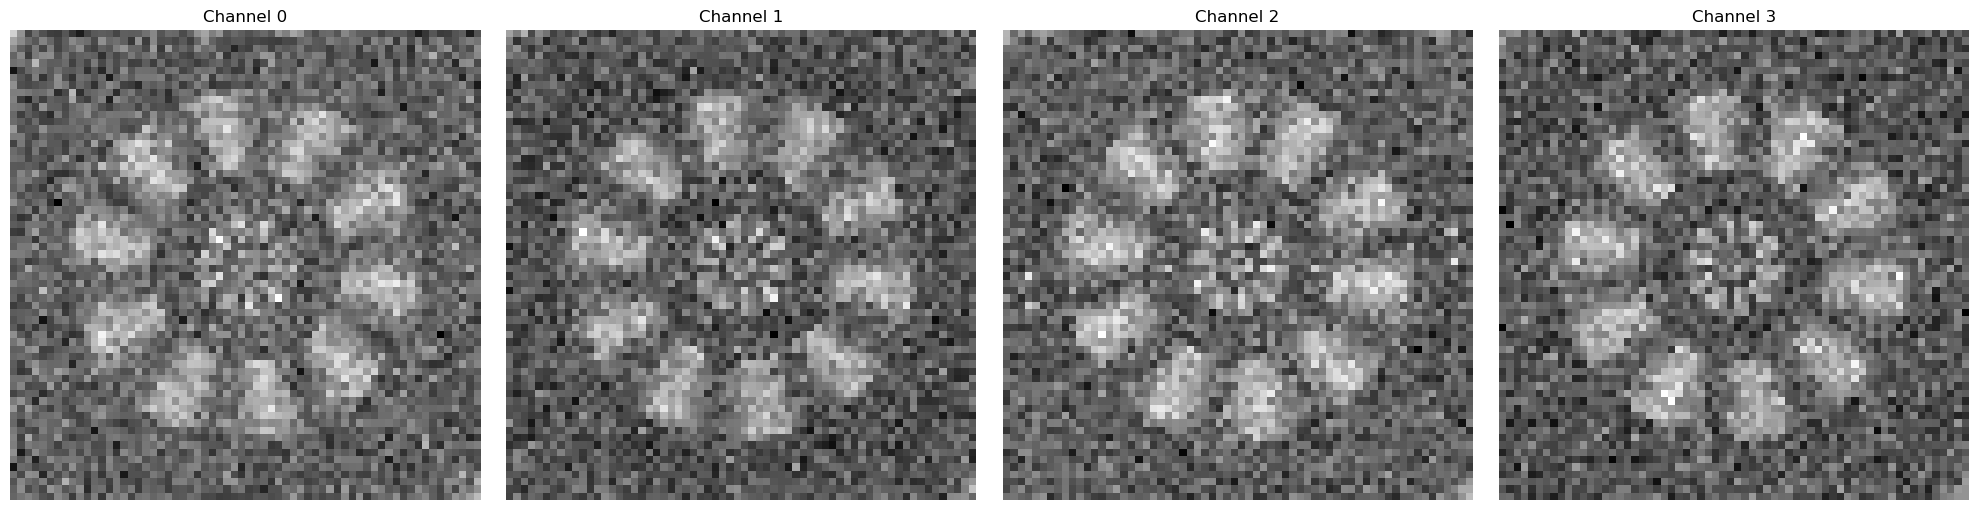

Pattern: octoweb
torch.complex32


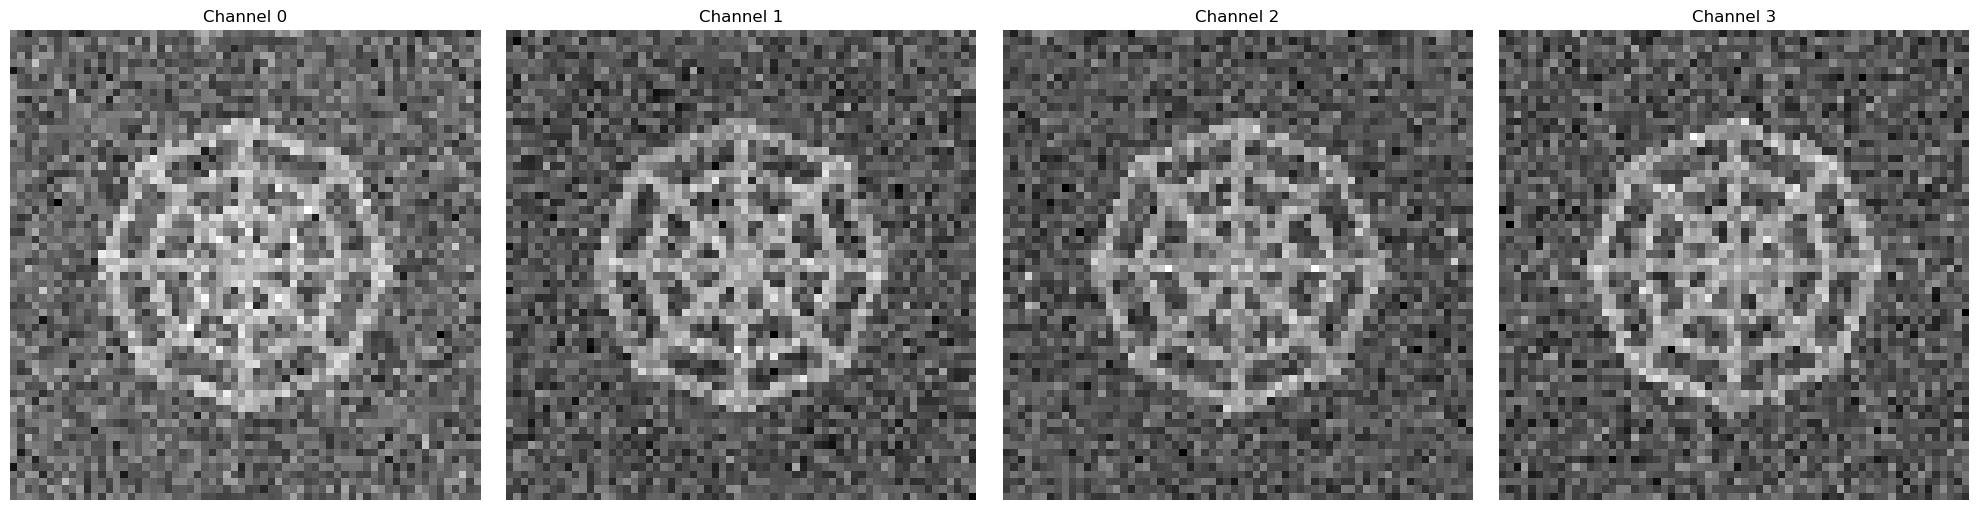

In [10]:
# Go through all the watermarking patterns to visualise them
for w_p in [
    "rand",
    "zeros",
    "const",
    "seed_rand",
    "seed_zeros",
    "seed_ring",
    "ring",
    "logpolar_grid",
    # "spiderweb",
    "octoweb",
]:
    print(f"Pattern: {w_p}")
    vis_patch = get_watermarking_pattern(
        pipe,
        w_seed=w_seed,
        w_pattern=w_p,
        w_radius=w_radius,
        device=device,
        shape=None,
        strength=0.98,
        n_spokes=8,
        n_levels=4,
        thickness_px=1.0,  # line thickness in pixels
        max_r_frac=.3,
    )
    print(vis_patch.dtype)
    visualise_noise(vis_patch[0])

In [11]:
# Generation parameters
gen_seed = 0
num_images = 1
guidance_scale = 7.5
num_inference_steps = 50
image_length = 512
set_random_seed(gen_seed)

# 3. Prepare latent for generation

In [12]:
i = 49 # Select an index from the dataset to generate the image
current_prompt = dataset[i][prompt_key]
# current_prompt = "A cute cat stretching, high quality, professional photography"
print(f"Prompt for generation: {current_prompt}")

Prompt for generation: Cloudscape by Adam Paquette, nebula gasses in the background by Gene Raz Von Edler, fantasy magic angel concept art from deviantart by Donato Giancola, Rendered in Octane, cinematic, Highly Detailed


## 3.1 Without watermarking

### Visualize the initial latents (noise) without watermarking

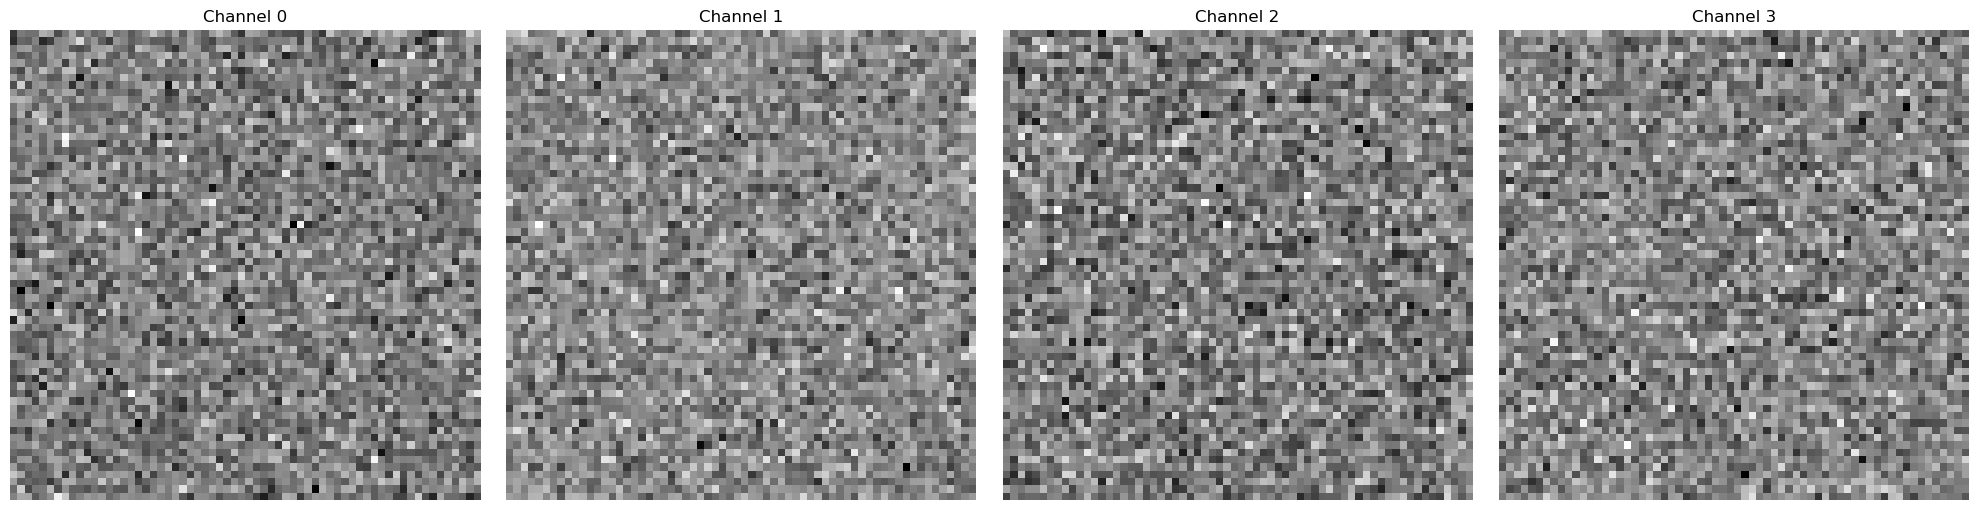

In [13]:
init_latents_no_w = pipe.get_random_latents()
visualise_noise(init_latents_no_w[0])

#### Generate the image from the initial latents without watermarking (normal pipeline)

In [14]:
num_inference_steps

50

In [15]:
outputs_no_w = pipe(
    current_prompt,
    num_images_per_prompt=num_images,
    guidance_scale=guidance_scale,  # how strongly to follow the prompt
    num_inference_steps=num_inference_steps,  # how many steps of denoising to do
    height=image_length,
    width=image_length,
    latents=init_latents_no_w,
)
orig_image_no_w = outputs_no_w.images[0]

  0%|          | 0/50 [00:00<?, ?it/s]

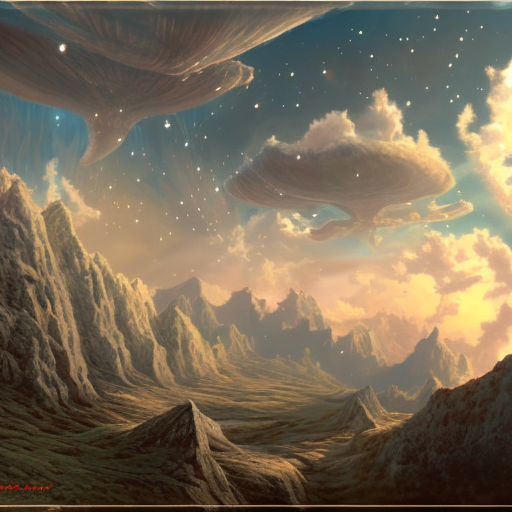

In [16]:
orig_image_no_w

## 3.2 With watermarking

In [17]:
# Use the same latent for generating the image with watermark
if init_latents_no_w is None:
    set_random_seed(gen_seed)
    init_latents_w = pipe.get_random_latents()
else:
    init_latents_w = copy.deepcopy(init_latents_no_w)

In [18]:
def get_watermarking_mask(
    init_latents_w,
    w_mask_shape: str,
    w_channel: int,
    w_radius: float,
    device: str,
):
    """
    Generate a watermarking mask based on the specified parameters.
    Parameters:
        - init_latents_w: The initial latents with watermarking.
        - w_mask_shape: The shape of the watermarking mask (e.g., "circle", "square").
        - w_channel: The channel to apply the watermarking mask to (-1 for all channels).
        - w_radius: The radius for the watermarking mask.
        - device: The device to use for computation (e.g., "cuda" or "cpu").
    Returns:
        - watermarking_mask: The generated watermarking mask.
    """
    watermarking_mask = torch.zeros(init_latents_w.shape, dtype=torch.bool).to(device)

    if w_mask_shape == "circle":
        np_mask = circle_mask(init_latents_w.shape[-1], r=w_radius)
        torch_mask = torch.tensor(np_mask).to(device)

        if w_channel == -1:
            # all channels
            watermarking_mask[:, :] = torch_mask
        else:
            watermarking_mask[:, w_channel] = torch_mask
    elif w_mask_shape == "square":
        anchor_p = init_latents_w.shape[-1] // 2
        if w_channel == -1:
            # all channels
            watermarking_mask[
                :,
                :,
                anchor_p - w_radius : anchor_p + w_radius,
                anchor_p - w_radius : anchor_p + w_radius,
            ] = True
        else:
            watermarking_mask[
                :,
                w_channel,
                anchor_p - w_radius : anchor_p + w_radius,
                anchor_p - w_radius : anchor_p + w_radius,
            ] = True
    elif w_mask_shape == "no":
        pass
    else:
        raise NotImplementedError(f"w_mask_shape: {w_mask_shape}")

    return watermarking_mask

## 🧱 Watermarking Mask ($\mathcal{M}$) Generation

The `get_watermarking_mask(...)` function constructs a **binary mask** (a tensor of `True`/`False` values) that determines **where** in the latent space the watermark should be applied during generation.

This mask is used to **localize perturbations** to specific spatial regions of the latent tensor $x_T \in \mathbb{R}^{B \times C \times H \times W}$, allowing for controlled watermark injection.

---

### 🧩 Supported Mask Shapes

| Shape      | Description                                                | Behavior                                                              |
| ---------- | ---------------------------------------------------------- | --------------------------------------------------------------------- |
| `"circle"` | Applies a circular region mask at the spatial center       | Mask created using `circle_mask(...)` from NumPy                      |
| `"square"` | Applies a square region centered in the spatial dimensions | Square of size $2 \times \text{radius} \times 2 \times \text{radius}$ |
| `"no"`     | Disables watermarking mask                                 | Returns an all-false mask                                             |

---

### 🧠 Channel Control (`w_channel`)

* If `w_channel = -1`: The mask is **broadcasted to all channels** in the latent.
* If `w_channel = c`: The mask is applied **only to the c-th channel**.

This allows testing different watermarking strategies such as:

* Injecting only in a **single semantic channel** (e.g., edge, texture),
* Applying noise across **all feature maps** equally.

---

### 📌 Output

Returns a boolean tensor `watermarking_mask` of the same shape as `init_latents_w`, where:

* `True` indicates positions that will be **perturbed with watermark noise**.
* `False` indicates positions that remain untouched.

In [19]:
watermarking_mask = get_watermarking_mask(
    init_latents_w,
    w_mask_shape="circle",
    w_channel=w_channel,
    w_radius=w_radius, 
    device=device,
)

### Visualise the watermarking mask

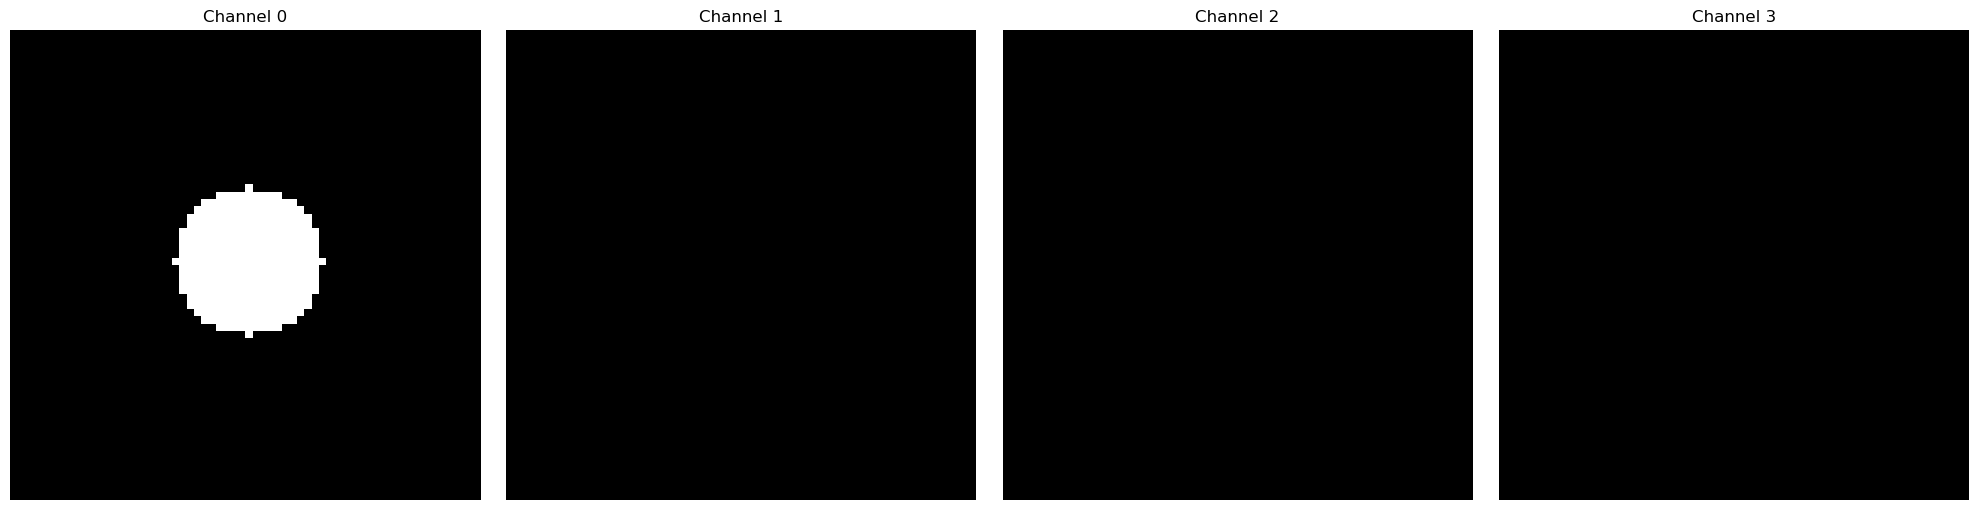

In [20]:
visualise_noise(watermarking_mask[0].float()) 

In [21]:
def inject_watermark(init_latents_w, watermarking_mask, gt_patch, w_injection: str):
    """
    Inject the watermark into the latents.
    Parameters:
        - init_latents_w: The initial latents with watermarking.
        - watermarking_mask: The mask indicating where to inject the watermark. (in the Fourier domain)
        - gt_patch: The watermark pattern to be injected.
        - w_injection: The method of watermark injection (e.g., "complex", "seed").
    Returns:
        - init_latents_w: The latents with the watermark injected.
    """

    # Perform FFT on the latents
    init_latents_w_fft = torch.fft.fftshift(torch.fft.fft2(init_latents_w), dim=(-1, -2))

    # Inject the watermark into the latents in FFT domain
    if w_injection == 'complex':
        init_latents_w_fft[watermarking_mask] = gt_patch[watermarking_mask].clone()
    elif w_injection == 'seed':
        init_latents_w[watermarking_mask] = gt_patch[watermarking_mask].clone()
        return init_latents_w
    else:
        NotImplementedError(f'w_injection: {w_injection}')

    # Perform inverse FFT to get the latents with watermark
    init_latents_w = torch.fft.ifft2(torch.fft.ifftshift(init_latents_w_fft, dim=(-1, -2))).real

    return init_latents_w

## 💧 Watermark Injection into Latents

The `inject_watermark(...)` function inserts a **watermark pattern** into a latent tensor $x_T \in \mathbb{R}^{B \times C \times H \times W}$ using a specified injection strategy and spatial mask. This step finalizes the preparation of watermarked noise for diffusion-based generation.

### 🔧 Parameters

* **`init_latents_w`**: The initial latent tensor intended to carry the watermark.
* **`watermarking_mask`**: A boolean tensor specifying which elements of the latent should be modified.
* **`gt_patch`**: The target watermark pattern, generated via `get_watermarking_pattern(...)`.
* **`w_injection`** (`str`): The injection method. Currently supports:

  * `"complex"`: Inject in the **Fourier domain**.
  * `"seed"`: Inject directly in the **spatial domain**.

---

### 💡 Injection Modes

| Injection Mode | Domain      | Description                                                                                                                                                             |
| -------------- | ----------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `"complex"`    | **Fourier** | Applies 2D FFT to the latent, injects watermark in frequency space (using mask), then performs inverse FFT. This is the **core method used in Tree-Ring watermarking**. |
| `"seed"`       | Spatial     | Injects `gt_patch` directly into `init_latents_w` using the binary mask in the spatial domain. This is simpler and used mainly for baselines or ablation studies.       |

---

### 🧠 Process Overview (Fourier Injection)

For the `"complex"` mode:

1. **Forward FFT**:
   The latent is transformed into the frequency domain:

   $$
   \mathcal{F}(x_T) = \text{fftshift}(\text{fft2}(x_T))
   $$

2. **Watermark Injection** (already in Fourier space):

   $$
   \mathcal{F}(x_T)_i \gets k^*_i \quad \text{for } i \in \mathcal{M}
   $$

   Where:

   * $\mathcal{F}(x_T)$ is the FFT of the latent,
   * $k^*_i$ comes from the watermark pattern `gt_patch`,
   * $\mathcal{M}$ is defined by `watermarking_mask`.

3. **Inverse FFT**:
   Transforms the modified latent back into the spatial domain:

   $$
   x_T^\text{marked} = \text{Re}\left[ \text{ifft2}(\text{ifftshift}(\mathcal{F}(x_T))) \right]
   $$

---

### 📌 Output

Returns a modified latent tensor `init_latents_w`:

* In the **Fourier-injected case**, this is a spatial-domain latent with a hidden watermark.
* In the **seed-injected case**, the spatial values are directly overwritten in-place.

This tensor is then passed into the Stable Diffusion pipeline to generate the watermarked image.



In [22]:
init_latents_w = inject_watermark(
    init_latents_w,
    watermarking_mask,
    gt_patch,
    w_injection=w_injection,
)

### Visualised the watermarked latents 

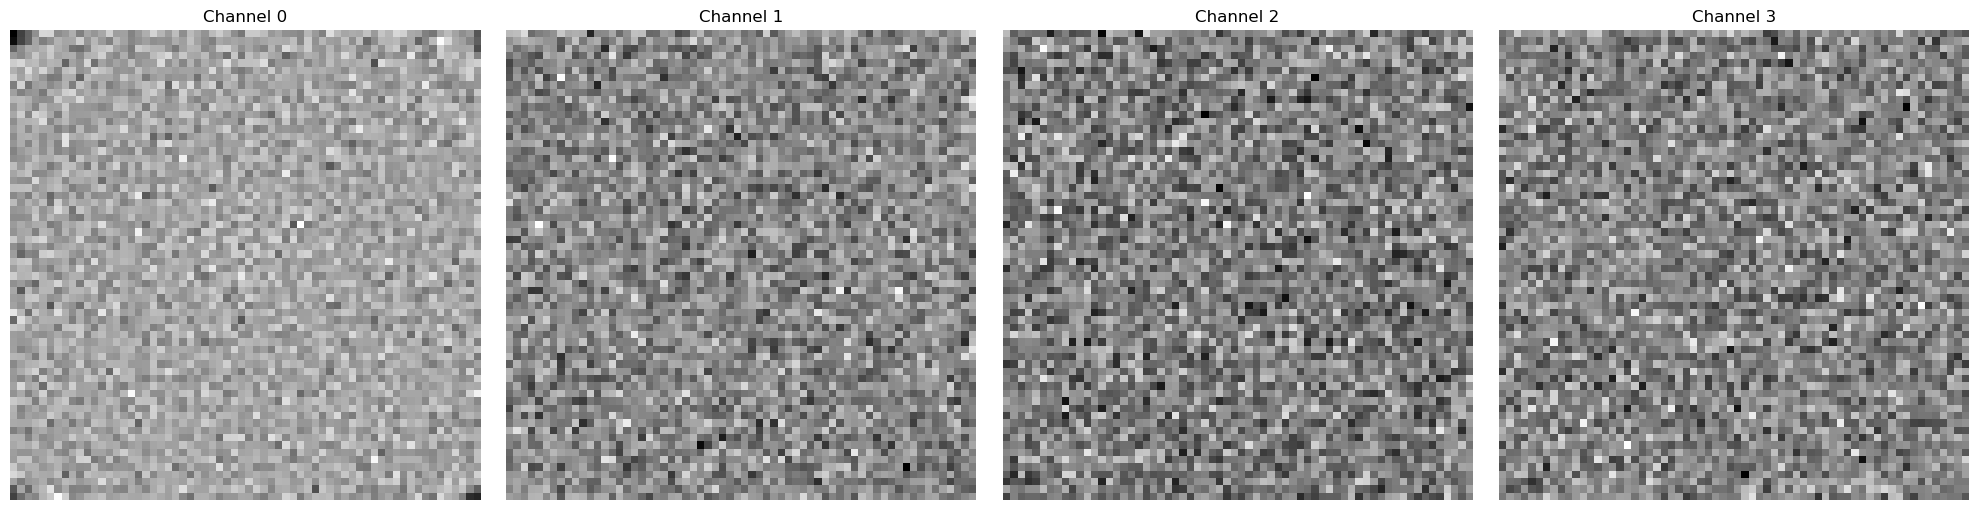

In [23]:
visualise_noise(init_latents_w[0])

In [24]:
outputs_w = pipe(
    current_prompt,
    num_images_per_prompt=num_images,
    guidance_scale=guidance_scale,
    num_inference_steps=num_inference_steps,
    height=image_length,
    width=image_length,
    latents=init_latents_w,
)
orig_image_w = outputs_w.images[0]

  0%|          | 0/50 [00:00<?, ?it/s]

### Compare watermarked and non-watermarked images

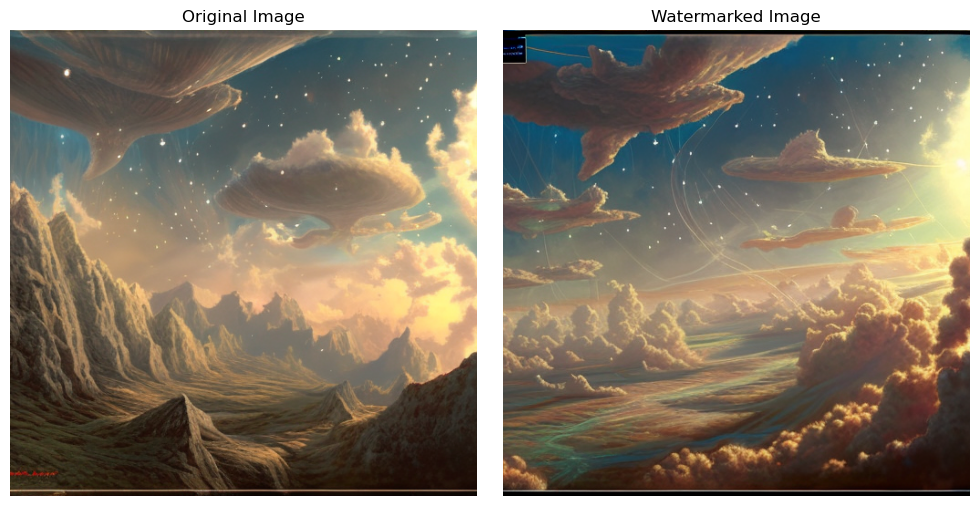

In [25]:
# visulise the original image and the watermarked image
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(orig_image_no_w)
axes[0].set_title("Original Image")
axes[0].axis("off")
axes[1].imshow(orig_image_w)
axes[1].set_title("Watermarked Image")
axes[1].axis("off")
plt.tight_layout()
plt.show()


# 4. Attack the images

In [26]:
from attack import Attacker
attacker = Attacker()

In [27]:
orig_image_no_w_auged = attacker.attack(orig_image_no_w)
orig_image_w_auged = attacker.attack(orig_image_w)

## 🎨 `image_distortion(...)`: Attack Watermarking Pattern via Image Distortion

The `image_distortion(...)` function applies a series of **controlled perturbations** to two input images using consistent randomness (via a seed). These distortions simulate realistic degradations, and can be used to test watermark robustness or image reconstruction fidelity.

---

### ⚙️ Transformations Applied

Each transform is applied **in sequence** and **symmetrically** to both images:

| Step | Transformation        | Description                                                                                        |
| ---- | --------------------- | -------------------------------------------------------------------------------------------------- |
| 1️⃣  | **Rotation**          | Rotates both images by exactly `r_degree`.                                                         |
| 2️⃣  | **JPEG Compression**  | Saves and reloads each image using the specified `jpeg_ratio` for lossy compression.               |
| 3️⃣  | **Random Cropping**   | Applies `RandomResizedCrop` with fixed seed to ensure the **same crop is applied** to both images. |
| 4️⃣  | **Gaussian Blur**     | Blurs both images using the specified blur radius.                                                 |
| 5️⃣  | **Gaussian Noise**    | Adds pixel-wise random Gaussian noise to simulate image corruption.                                |
| 6️⃣  | **Brightness Jitter** | Adjusts brightness using `ColorJitter` for consistent lighting perturbation.                       |

## Visualise the distored images

In [28]:
orig_image_w_auged.size

(512, 512)

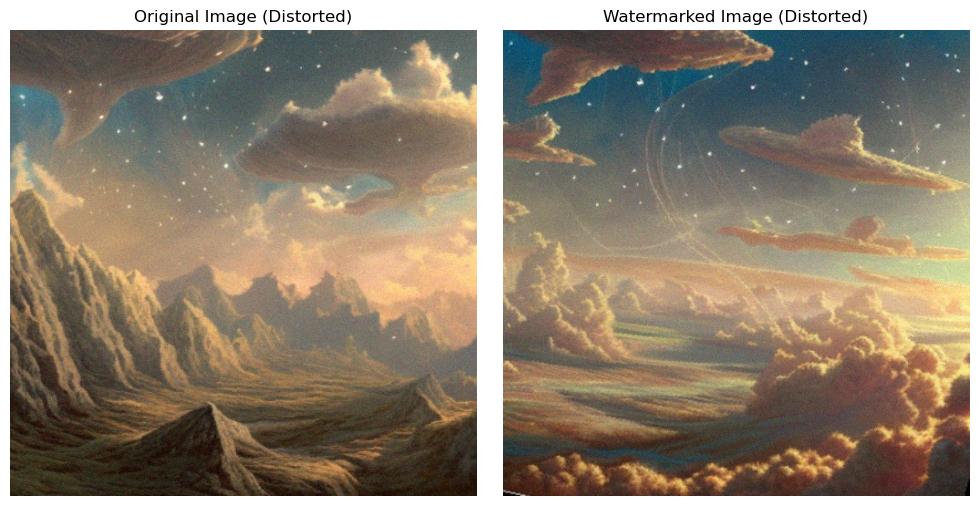

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(orig_image_no_w_auged)
axes[0].set_title("Original Image (Distorted)")
axes[0].axis("off")
axes[1].imshow(orig_image_w_auged)
axes[1].set_title("Watermarked Image (Distorted)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

In [30]:
from torchvision import transforms
def transform_img(image, target_size=512):
    tform = transforms.Compose(
        [
            transforms.Resize(target_size),
            transforms.CenterCrop(target_size),
            transforms.ToTensor(),
            transforms.ConvertImageDtype(torch.float32),
        ]
    )
    image = tform(image)
    return 2.0 * image - 1.0

# 5. From Image to Latents

In [31]:
# reverse img without watermarking
img_no_w = transform_img(orig_image_no_w_auged).unsqueeze(0).to(text_embeddings.dtype).to(device)
image_latents_no_w = pipe.get_image_latents(img_no_w, sample=False)

reversed_latents_no_w = pipe.forward_diffusion(
    latents=image_latents_no_w,
    text_embeddings=text_embeddings,
    guidance_scale=1,
    num_inference_steps=num_inference_steps,
)

# reverse img with watermarking
img_w = transform_img(orig_image_w_auged).unsqueeze(0).to(text_embeddings.dtype).to(device)
image_latents_w = pipe.get_image_latents(img_w, sample=False)

reversed_latents_w = pipe.forward_diffusion(
    latents=image_latents_w,
    text_embeddings=text_embeddings,
    guidance_scale=1,
    num_inference_steps=num_inference_steps,
)


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

In [32]:
import torch.nn.functional as F
import torch

def _compute_psnr_masked(pred, target, mask, eps=1e-8):
    """
    Fallback PSNR on masked region: 10*log10(MAX^2 / MSE_masked).
    Assumes inputs in [0,1] or any bounded range; uses dynamic MAX from target.
    """
    # restrict to mask
    diff = (pred - target)[mask]
    mse = (diff.float() ** 2).mean().clamp_min(eps)
    # dynamic range from target over mask
    t = target[mask].float()
    max_val = (t.max() - t.min()).clamp_min(eps)
    # if target is constant, fall back to 1.0 range
    if max_val.item() == 0.0:
        max_val = torch.tensor(1.0, device=t.device)
    psnr = 10.0 * torch.log10((max_val ** 2) / mse)
    return psnr.item()

def eval_watermark(
    latent: torch.Tensor,
    watermarking_mask: torch.Tensor,
    gt_patch: torch.Tensor,
    w_measurement: str,
) -> float:
    """
    Evaluate watermark quality for a SINGLE latent against gt_patch on watermarking_mask.

    Args:
        latent:              Tensor [..., H, W] or [..., C, H, W] (last two dims are H,W).
        watermarking_mask:   Bool/byte mask broadcastable to latent/gt_patch spatial dims.
        gt_patch:            Ground-truth pattern tensor, same shape as latent (or broadcastable).
        w_measurement:       e.g. "complex+l1", "seed+l1", "complex+psnr", "seed+psnr".

    Returns:
        metric: float scalar.
    """
    # choose domain
    if "complex" in w_measurement:
        # FFT over spatial dims (H, W); shift to center
        latent_dom = torch.fft.fftshift(torch.fft.fft2(latent), dim=(-1, -2))
        target_dom = gt_patch
    elif "seed" in w_measurement:
        # real domain
        latent_dom = latent
        target_dom = gt_patch
    else:
        raise NotImplementedError(f"w_measurement domain not recognized: {w_measurement}")

    # ensure mask is boolean and broadcastable to spatial dims
    wm_mask = watermarking_mask.bool()

    # metric
    if "l1" in w_measurement:
        metric = torch.abs(latent_dom[wm_mask] - target_dom[wm_mask]).mean().item()
    elif "psnr" in w_measurement:
        # try user's compute_psnr first (signature: (pred, target, mask))
        if "compute_psnr" in globals() and callable(globals()["compute_psnr"]):
            metric = globals()["compute_psnr"](latent_dom, target_dom, wm_mask)
        else:
            metric = _compute_psnr_masked(latent_dom, target_dom, wm_mask)
    else:
        raise NotImplementedError(f"w_measurement metric not recognized: {w_measurement}")

    return metric

## 📏 `eval_watermark(...)`: Watermark Evaluation Function

The `eval_watermark(...)` function measures how well a watermark is preserved or detectable in latent representations. It compares both **watermarked** and **non-watermarked** latents against a known **ground truth watermark pattern** (`gt_patch`) within a defined **mask region**.

---

### 🧭 Supported Evaluation Modes

`w_measurement` is a string that defines **both the domain** and **the comparison metric**.

| Domain      | Description                                                                                                   |
| ----------- | ------------------------------------------------------------------------------------------------------------- |
| `"complex"` | Compares in the **Fourier domain** using `fft2` + `fftshift`. Used for watermark injected in frequency space. |
| `"seed"`    | Compares in the **spatial domain** (real space). Used for seed-based watermarking or ablations.               |

| Metric   | Description                                                                                     |
| -------- | ----------------------------------------------------------------------------------------------- |
| `"l1"`   | Computes **mean absolute error** (L1 distance) between reconstructed and target pattern.        |
| `"psnr"` | Computes **Peak Signal-to-Noise Ratio (PSNR)** in dB to quantify similarity — higher is better. |

You can combine both as `w_measurement="complex_l1"`, `"seed_psnr"`, etc.

---

### 📐 What It Measures

For both `reversed_latents_no_w` and `reversed_latents_w`, the function computes:

#### L1 (Mean Absolute Error)

$$
\text{L1\_distance} = \frac{1}{|\mathcal{M}|} \sum_{i \in \mathcal{M}} \left| x_i - k^*_i \right|
$$

#### PSNR (Peak Signal-to-Noise Ratio)

$$
\text{PSNR} = 10 \cdot \log_{10} \left( \frac{\text{MAX}^2}{\text{MSE}} \right)
\quad\text{where}\quad
\text{MSE} = \frac{1}{|\mathcal{M}|} \sum_{i \in \mathcal{M}} (x_i - k^*_i)^2
$$

Where:

* $\mathcal{M}$ is the watermarking mask,
* $x_i$ is the latent value (in spatial or Fourier domain),
* $k^*_i$ is the watermark key (from `gt_patch`),
* `MAX` is the maximum value in the domain (default: 1.0, but may vary depending on scale).

---

### ✅ Metric Interpretation

| Metric | Better Value | Interpretation                                                                    |
| ------ | ------------ | --------------------------------------------------------------------------------- |
| `L1`   | Lower        | Smaller distance means the watermark is more closely preserved.                   |
| `PSNR` | Higher       | Larger PSNR means lower error and better reconstruction of the watermark pattern. |

A strong watermark should yield:

* `no_w_metric` ≫ `w_metric` (L1)
* `psnr_w_metric` ≫ `psnr_no_w_metric` (PSNR)

---

### 📌 Output

```python
no_w_metric, w_metric = eval_watermark(...)
```

Where both are floats representing the L1 distance **or** PSNR (depending on the metric used), calculated between the latent (in real or FFT domain) and the watermark patch, masked to the target region.



# 5. Evaluate the watermarking performance through measuring the distance of the image to the gt_pattern.

In [33]:
try:
    from scipy.stats import ncx2
except Exception as e:
    ncx2 = None
    _scipy_import_error = e

# requires: numpy, torch, matplotlib (for plotting), scipy
import numpy as np
import torch
try:
    from scipy.stats import ncx2
except Exception as e:
    ncx2 = None
    _scipy_import_error = e

def _ensure_mask_shape(mask, ref_tensor):
    if not torch.is_tensor(mask):
        mask = torch.tensor(mask)
    mask = mask.bool()
    if mask.ndim == 2:
        mask = mask.unsqueeze(0).unsqueeze(0)  # 1,1,H,W
    if mask.shape != ref_tensor.shape:
        mask = mask.expand(ref_tensor.shape)
    return mask

def detect_watermark_ncx2_from_latent(
    latent_tensor,            # torch tensor (B,C,H,W)
    gt_patch,                 # key (either in freq domain or spatial)
    watermarking_mask,        # boolean mask selecting frequency bins M (H,W or B,C,H,W)
    k_in_freq_domain=True,
    alpha=0.01,
    eps=1e-12,
    verbose=True,
):
    if ncx2 is None:
        raise RuntimeError("scipy required for noncentral chi2. Import error: %s" % (_scipy_import_error,))

    # Ensure batch dim
    if latent_tensor.ndim == 3:
        latent_tensor = latent_tensor.unsqueeze(0)
    B, C, H, W = latent_tensor.shape
    if B != 1 and verbose:
        print("Warning: only processing first sample of batch")
        latent_tensor = latent_tensor[0:1]

    device = latent_tensor.device

    # compute y_fft in standard convention (fft2 + fftshift)
    # ensure we do FFT on float32 inputs so output complex dtype becomes complex64
    y_input = latent_tensor
    if y_input.dtype == torch.float16 or y_input.dtype == torch.bfloat16:
        y_input = y_input.to(torch.float32)
    y_fft = torch.fft.fftshift(torch.fft.fft2(y_input), dim=(-1, -2))  # complex dtype (likely complex64)

    # prepare key in Fourier domain
    if k_in_freq_domain:
        k_fft = gt_patch
        # If user passed a float tensor rather than complex, convert to fft
        if not torch.is_complex(k_fft):
            if k_fft.ndim == 3:
                k_fft = k_fft.unsqueeze(0)
            k_tmp = k_fft
            if k_tmp.dtype == torch.float16 or k_tmp.dtype == torch.bfloat16:
                k_tmp = k_tmp.to(torch.float32)
            k_fft = torch.fft.fftshift(torch.fft.fft2(k_tmp), dim=(-1, -2))
    else:
        k_tmp = gt_patch
        if k_tmp.ndim == 3:
            k_tmp = k_tmp.unsqueeze(0)
        if k_tmp.dtype == torch.float16 or k_tmp.dtype == torch.bfloat16:
            k_tmp = k_tmp.to(torch.float32)
        k_fft = torch.fft.fftshift(torch.fft.fft2(k_tmp), dim=(-1, -2))

    # ensure shapes align (replicate channels if necessary)
    if k_fft.shape != y_fft.shape:
        if k_fft.shape[0] == 1 and y_fft.shape[0] == 1 and k_fft.shape[1] == 1 and y_fft.shape[1] > 1:
            k_fft = k_fft.repeat(1, y_fft.shape[1], 1, 1)
        else:
            raise ValueError(f"Shape mismatch y_fft {y_fft.shape} vs k_fft {k_fft.shape}")

    # Convert complex-half types to complex64 before moving to CPU / numpy
    if y_fft.is_complex() and y_fft.dtype != torch.complex64 and y_fft.dtype != torch.complex128:
        # prefer complex64
        y_fft = y_fft.to(torch.complex64)
    if k_fft.is_complex() and k_fft.dtype != torch.complex64 and k_fft.dtype != torch.complex128:
        k_fft = k_fft.to(torch.complex64)

    # prepare mask on CPU for indexing
    mask = _ensure_mask_shape(watermarking_mask, y_fft)  # boolean on same shape
    mask_cpu = mask.detach().cpu()

    # Move fft tensors to CPU (complex64) for numpy/scipy interaction
    y_cpu = y_fft.detach().cpu()
    k_cpu = k_fft.detach().cpu()

    # select masked elements and flatten
    y_sel = y_cpu[mask_cpu].numpy().astype(np.complex128).ravel()
    k_sel = k_cpu[mask_cpu].numpy().astype(np.complex128).ravel()

    M = y_sel.size
    if M == 0:
        raise ValueError("Empty watermark mask (|M|=0)")

    # compute sigma2, eta, lam in numpy (scalars)
    sigma2 = float(np.mean(np.abs(y_sel)**2))
    sigma2 = max(sigma2, eps)
    eta = (1.0 / sigma2) * float(np.sum(np.abs(k_sel - y_sel)**2))
    lam = (1.0 / sigma2) * float(np.sum(np.abs(k_sel)**2))

    # p-value and threshold via non-central chi2
    p_value = float(ncx2.cdf(eta, df=M, nc=lam))
    try:
        threshold_eta = float(ncx2.ppf(alpha, df=M, nc=lam))
    except Exception:
        threshold_eta = None

    detected = (p_value <= alpha)

    if verbose:
        print(f"ncx2 test: M={M}, sigma2={sigma2:.4e}, eta={eta:.4f}, lam={lam:.4f}, p={p_value:.4e}, alpha={alpha}, detected={detected}")
    return dict(
        p_value=p_value,
        eta=eta,
        threshold_eta=threshold_eta,
        detected=bool(detected),
        sigma2=sigma2,
        M=int(M),
        lam=lam,
        alpha=float(alpha),
    )

# ---------------------------
# Full integrated verify function
# ---------------------------
def verify_with_ncx2(
    image,
    pipe,
    text_embeddings,
    watermarking_mask,
    gt_patch,
    num_inference_steps,
    alpha=0.01,
    k_in_freq_domain=True,
    show_visual=True,
    device=None,
):
    """
    Integrates the paper's ncx2 test into your verify routine.
    Parameters:
      - image: PIL or np array as before
      - pipe: your diffusion pipeline with get_image_latents and forward_diffusion
      - text_embeddings: embeddings used in forward_diffusion call (if needed)
      - watermarking_mask: boolean mask in frequency domain (H,W) or (1,C,H,W)
      - gt_patch: your key (if k_in_freq_domain True, gt_patch must already be in FFT domain or same shape)
      - num_inference_steps: used when calling forward_diffusion (your pipeline)
      - alpha: significance level (paper uses 0.01)
      - k_in_freq_domain: whether gt_patch is already Fourier (True by default)
    Returns:
      - results dict with detection & metrics
    """
    if device is None:
        device = next(pipe.unet.parameters()).device if hasattr(pipe, "unet") else torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # show image
    if show_visual:
        plt.figure(figsize=(4,4))
        plt.imshow(image)
        plt.axis("off")
        plt.show()

    # to tensor and move to dtype/device expected by pipeline
    tsr_img = transform_img(image).unsqueeze(0).to(next(pipe.unet.parameters()).dtype).to(device)
    print(tsr_img.shape, tsr_img.dtype)  # torch.Size([1, 3, 512, 512]) torch.float16
    # encode to image latents (user's helper)
    image_latents = pipe.get_image_latents(tsr_img, sample=False)
    print(image_latents.shape, image_latents.dtype) # torch.Size([1, 4, 64, 64]) torch.float16
    
    reversed_latents = pipe.forward_diffusion(
        latents=image_latents,
        text_embeddings=text_embeddings,
        guidance_scale=1,
        num_inference_steps=num_inference_steps,
    )

    # Visualise in Fourier domain (keep as complex)
    vis_latent_fft = torch.fft.fftshift(torch.fft.fft2(reversed_latents), dim=(-1,-2))
    
    if show_visual:
        # display magnitude for first channel
        mag = vis_latent_fft[0,0].abs().detach().cpu().numpy()
        plt.figure(figsize=(4,4))
        plt.title("FFT magnitude (reversed_latents)")
        plt.imshow(np.log1p(mag), cmap="magma")
        plt.axis("off")
        plt.show()


    # compute l1/psnr metrics if you still want them (assuming eval_watermark accepts complex tensors)
    l1_metric = None
    psnr_metric = None
    try:
        l1_metric = eval_watermark(reversed_latents, watermarking_mask, gt_patch, w_measurement="l1_complex")
        psnr_metric = eval_watermark(reversed_latents, watermarking_mask, gt_patch, w_measurement="psnr_complex")
    except Exception as e:
        # not fatal — just print
        print("Warning: eval_watermark failed:", e)

    # run statistical test (paper)
    stats = detect_watermark_ncx2_from_latent(
        latent_tensor=reversed_latents,
        gt_patch=gt_patch,
        watermarking_mask=watermarking_mask,
        k_in_freq_domain=k_in_freq_domain,
        alpha=alpha,
        verbose=True,
    )

    # nicely return all info
    results = dict(
        l1_metric=l1_metric,
        psnr_metric=psnr_metric,
        ncx2_stats=stats,
    )
    return results

In [34]:
w_pattern, w_mask_shape

('ring', 'circle')

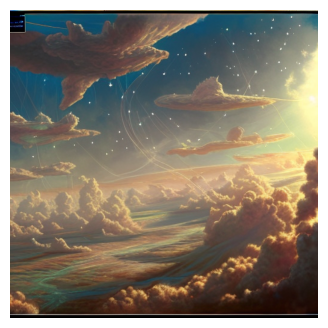

torch.Size([1, 3, 512, 512]) torch.float16
torch.Size([1, 4, 64, 64]) torch.float16


  0%|          | 0/50 [00:00<?, ?it/s]

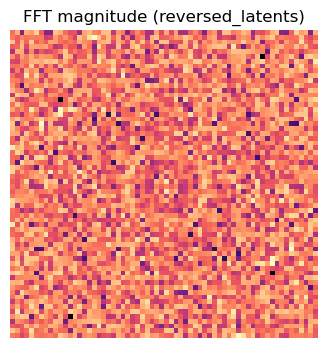

ncx2 test: M=317, sigma2=3.4871e+03, eta=261.7863, lam=600.2007, p=2.3372e-59, alpha=0.01, detected=True


{'l1_metric': 46.5625,
 'psnr_metric': 9.053123474121094,
 'ncx2_stats': {'p_value': 2.3372145956725896e-59,
  'eta': 261.7863399744583,
  'threshold_eta': 793.1798736903968,
  'detected': True,
  'sigma2': 3487.0632794582534,
  'M': 317,
  'lam': 600.2007380911996,
  'alpha': 0.01}}

In [35]:
verify_with_ncx2(
    orig_image_w,
    pipe,
    text_embeddings,
    watermarking_mask,
    gt_patch,
    num_inference_steps,
    alpha=0.01,
    k_in_freq_domain=True,
    show_visual=True,
    device=None,
)

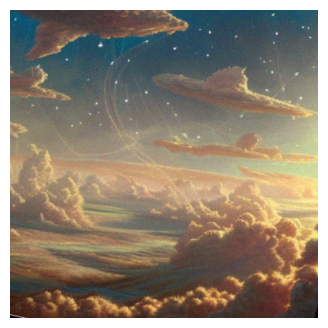

torch.Size([1, 3, 512, 512]) torch.float16
torch.Size([1, 4, 64, 64]) torch.float16


  0%|          | 0/50 [00:00<?, ?it/s]

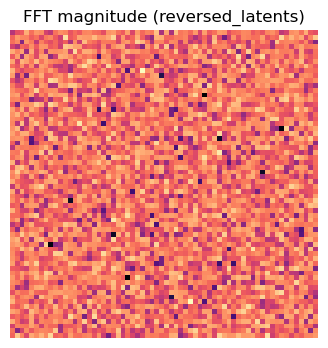

ncx2 test: M=317, sigma2=3.9616e+03, eta=848.5182, lam=528.3019, p=5.3144e-01, alpha=0.01, detected=False


{'l1_metric': 90.875,
 'psnr_metric': 2.5075936317443848,
 'ncx2_stats': {'p_value': 0.5314429610553386,
  'eta': 848.5181685492706,
  'threshold_eta': 727.4727453100536,
  'detected': False,
  'sigma2': 3961.6326559610748,
  'M': 317,
  'lam': 528.3018734592456,
  'alpha': 0.01}}

In [36]:
verify_with_ncx2(
    orig_image_w_auged,
    pipe,
    text_embeddings,
    watermarking_mask,
    gt_patch,
    num_inference_steps,
    alpha=0.01,
    k_in_freq_domain=True,
    show_visual=True,
    device=None,
)

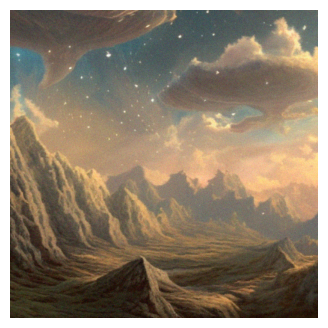

torch.Size([1, 3, 512, 512]) torch.float16
torch.Size([1, 4, 64, 64]) torch.float16


  0%|          | 0/50 [00:00<?, ?it/s]

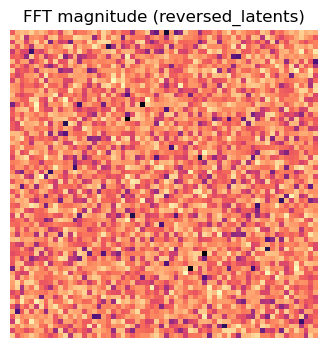

ncx2 test: M=317, sigma2=4.1421e+03, eta=817.0942, lam=505.2858, p=4.6691e-01, alpha=0.01, detected=False


{'l1_metric': 90.5,
 'psnr_metric': 2.5269217491149902,
 'ncx2_stats': {'p_value': 0.4669083573376276,
  'eta': 817.0941969797674,
  'threshold_eta': 706.5054923454593,
  'detected': False,
  'sigma2': 4142.087585102994,
  'M': 317,
  'lam': 505.28577947719106,
  'alpha': 0.01}}

In [37]:
verify_with_ncx2(
    orig_image_no_w_auged,
    pipe,
    text_embeddings,
    watermarking_mask,
    gt_patch,
    num_inference_steps,
    alpha=0.01,
    k_in_freq_domain=True,
    show_visual=True,
    device=None,
)


In [40]:
chosen[:5]

[15577, 34363, 30036, 46687, 57823]

In [ ]:
# Cell: build_watermark_detection_dataset
import os, random, math
from pathlib import Path
from PIL import Image
import torch
from tqdm.auto import tqdm
from datasets import load_dataset

# ---------- USER CONFIG ----------
hf_dataset_name = "Gustavosta/Stable-Diffusion-Prompts"
split = "train"
n_per_class = 500  # number of pairs (clean + watermarked)
out_dir = Path(f"watermark_dataset_stablediff_{w_pattern}")
seed = 42
# num_inference_steps = 50
# guidance_scale = 7.5

# watermark params (tune as you like)
# w_seed_base = 1000
# w_pattern = "logpolar_grid"  # one of your supported patterns
# w_radius = 12
# w_injection = "complex"  # or 'seed' depending on your inject_watermark implementation
# strength = 0.08
# ---------------------------------

out_clean_dir = out_dir / "clean"
out_w_dir = out_dir / "watermarked"
out_clean_dir.mkdir(parents=True, exist_ok=True)
out_w_dir.mkdir(parents=True, exist_ok=True)

# load prompts
ds = load_dataset(hf_dataset_name, split=split)
prompt_key = "Prompt"
if prompt_key is None:
    raise RuntimeError(f"Prompt column not found in dataset columns: {ds.column_names}")

# deterministic selection
rng = random.Random(seed)
indices = list(range(len(ds)))
rng.shuffle(indices)
chosen = indices[:n_per_class]

# save chosen prompts
chosen_prompts = [ds[i][prompt_key] for i in chosen]
with open(out_dir / "chosen_prompts.txt", "w", encoding="utf-8") as f:
    for prompt in chosen_prompts:
        f.write(prompt + "\n")

raise StopIteration("Dataset building cell only; adjust params and run generation cell next.")


# infer device/dtype from pipe.unet if possible
try:
    unet_param = next(pipe.unet.parameters())
    default_device = unet_param.device
    default_dtype = unet_param.dtype
except Exception:
    default_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    default_dtype = torch.float32


def ensure_pil(img):
    # accepts PIL, numpy (H,W,C), or tensor (C,H,W) or (B,C,H,W)
    if isinstance(img, Image.Image):
        return img
    if isinstance(img, torch.Tensor):
        if img.ndim == 4:
            img = img[0]
        arr = img.detach().cpu().permute(1, 2, 0).numpy()
        # arr expected in [0,1] or [0,255]
        if arr.dtype == "float32" or arr.dtype == "float64":
            arr = (arr * 255).clip(0, 255).astype("uint8")
        return Image.fromarray(arr)
    # numpy array
    import numpy as np

    if isinstance(img, (np.ndarray,)):
        arr = img
        if arr.dtype in (np.float32, np.float64):
            arr = (arr * 255).clip(0, 255).astype("uint8")
        return Image.fromarray(arr)
    raise RuntimeError("Unsupported image type")


# a robust getter for a random latent without writing new helpers
def obtain_random_latents_from_pipe():
    # 1) try no-arg get_random_latents()
    try:
        lat = pipe.get_random_latents()
        if isinstance(lat, torch.Tensor):
            return lat
        # sometimes returns wrapper
        if hasattr(lat, "latents"):
            return lat.latents
        if isinstance(lat, (tuple, list)) and isinstance(lat[0], torch.Tensor):
            return lat[0]
    except Exception:
        pass

    # 2) try prepare_latents (typical diffusers)
    try:
        if hasattr(pipe, "prepare_latents"):
            # try typical signature
            try:
                # infer shape
                ch = getattr(pipe.unet.config, "in_channels", 4)
                sample_size = getattr(pipe.unet.config, "sample_size", 64)
                if isinstance(sample_size, int):
                    H = W = sample_size
                else:
                    H = sample_size[0]
                    W = sample_size[1] if len(sample_size) > 1 else sample_size[0]
                lat = pipe.prepare_latents(
                    batch_size=1, num_images_per_prompt=1, height=H, width=W
                )
                if isinstance(lat, torch.Tensor):
                    return lat
                if hasattr(lat, "latents"):
                    return lat.latents
            except TypeError:
                # try bare call
                try:
                    lat = pipe.prepare_latents()
                    if isinstance(lat, torch.Tensor):
                        return lat
                    if hasattr(lat, "latents"):
                        return lat.latents
                except Exception:
                    pass
    except Exception:
        pass

    # 3) fallback random tensor based on unet config
    try:
        sample_size = getattr(pipe.unet.config, "sample_size", 64)
        in_ch = getattr(pipe.unet.config, "in_channels", 4)
        if isinstance(sample_size, int):
            H = W = sample_size
        else:
            H = sample_size[0]
            W = sample_size[1] if len(sample_size) > 1 else sample_size[0]
        lat = torch.randn(1, in_ch, H, W, device=default_device, dtype=default_dtype)
        return lat
    except Exception:
        return torch.randn(1, 4, 64, 64, device=default_device, dtype=default_dtype)


# main loop
for i, ds_idx in tqdm(list(enumerate(chosen)), desc="generating", total=len(chosen)):
    prompt = ds[ds_idx][prompt_key]
    sample_seed = seed + i + 1

    # 1) base latent (no args)
    init_latents = obtain_random_latents_from_pipe()
    init_latents = init_latents.to(default_device)
    try:
        init_latents = init_latents.to(default_dtype)
    except Exception:
        pass

    # 2) mask and pattern using your notebook helpers
    watermarking_mask = get_watermarking_mask(
        init_latents,
        w_mask_shape=w_mask_shape,
        w_channel=w_channel,
        w_radius=w_radius,
        device=default_device,
    )

    gt_patch = get_watermarking_pattern(
        pipe,
        w_seed=w_seed + i,
        w_pattern=w_pattern,
        w_radius=w_radius,
        device=device,
        strength=w_strength,
        shape=None,
    )

    # 3) dtype-safe injection attempts (use your inject_watermark)
    lat_clean = init_latents.clone()
    lat_w = None

    # detect FFT dtype of the latents (what inject might expect for complex injection)
    try:
        fft_example = torch.fft.fft2(lat_clean)
        fft_dtype = fft_example.dtype
        is_fft_complex = torch.is_complex(fft_example)
    except Exception:
        fft_dtype = None
        is_fft_complex = False

    # Try direct injection, otherwise try casting gt_patch to a compatible dtype
    try:
        lat_w = inject_watermark(
            lat_clean.clone(),
            watermarking_mask,
            gt_patch.clone(),
            w_injection=w_injection,
        )
    except Exception as e:
        # common dtype mismatch: complex vs real half/float
        tried = False
        if fft_dtype is not None and is_fft_complex:
            # create complex gt_patch in the same complex dtype, using real part = gt_patch, imag = 0
            try:
                # map real -> float32 then to complex if needed
                real_dtype = (
                    torch.float32 if fft_dtype == torch.complex64 else torch.float64
                )
                gp_real = gt_patch.clone().to(device=default_device).to(real_dtype)
                gp_complex = gp_real.to(fft_dtype)  # cast to complex dtype (zero imag)
                lat_w = inject_watermark(
                    lat_clean.clone(),
                    watermarking_mask,
                    gp_complex,
                    w_injection=w_injection,
                )
                tried = True
            except Exception:
                tried = False
        if not tried:
            # last fallback: try injecting with seed-mode (real-space) if available
            try:
                lat_w = inject_watermark(
                    lat_clean.clone(),
                    watermarking_mask,
                    gt_patch.clone().to(default_dtype),
                    w_injection="seed",
                )
                tried = True
            except Exception:
                tried = False
        if not tried:
            raise RuntimeError(
                f"inject_watermark failed (original error: {e}). Tried complex-cast and 'seed' fallback but both failed."
            )

    if lat_w is None:
        raise RuntimeError("Failed to produce watermarked latents (lat_w is None)")

    # 4) produce images with pipe (prefer passing latents)
    try:
        out_clean = pipe(
            prompt=prompt,
            latents=init_latents,
            num_inference_steps=num_inference_steps,
            guidance_scale=guidance_scale,
        )
        im_clean = out_clean.images if hasattr(out_clean, "images") else out_clean[0]
    except Exception:
        # fallback to prompt-only generation
        out_clean = pipe(
            prompt=prompt,
            num_inference_steps=num_inference_steps,
            guidance_scale=guidance_scale,
        )
        im_clean = out_clean.images if hasattr(out_clean, "images") else out_clean[0]

    try:
        out_w = pipe(
            prompt=prompt,
            latents=lat_w,
            num_inference_steps=num_inference_steps,
            guidance_scale=guidance_scale,
        )
        im_w = out_w.images if hasattr(out_w, "images") else out_w[0]
    except Exception:
        out_w = pipe(
            prompt=prompt,
            num_inference_steps=num_inference_steps,
            guidance_scale=guidance_scale,
        )
        im_w = out_w.images if hasattr(out_w, "images") else out_w[0]

    pil_clean = ensure_pil(im_clean[0])
    pil_w = ensure_pil(im_w[0])

    fname = f"{i:04d}"
    pil_clean.save(out_clean_dir / f"{fname}.png")
    pil_w.save(out_w_dir / f"{fname}.png")

print("Saved dataset to:", out_dir)

StopIteration: Dataset building cell only; adjust params and run generation cell next.

[<PIL.Image.Image image mode=RGB size=512x512>]